In [1]:
import warnings
from matplotlib.backends.backend_pdf import PdfPages
from src.sgtlib.utils.sgt_utils import sgt_excel_to_dataframe, sgt_scaling_plot

warnings.filterwarnings("ignore", category=RuntimeWarning)
# Uncomment to install Libraries (if not installed)
#!pip3 install openpyxl

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from scipy.stats import norm

# -----------------------------
# 1. Simulate synthetic data
# -----------------------------
np.random.seed(42)

N = np.random.randint(50, 2000, size=400)          # node counts
alpha0, alpha1 = -2.0, 0.8                         # mean params
beta0,  beta1  = 0.5,  0.1                         # std params

mu = alpha0 + alpha1 * np.log(N)
sigma = np.clip(beta0 + beta1 * np.log(N), 1e-3, None)
X = np.exp(np.random.normal(mu, sigma))             # lognormal samples

df = pd.DataFrame({"N": N, "X": X})
df["logN"] = np.log(df["N"])
df["logX"] = np.log(df["X"])

# -----------------------------
# 2. Define log-likelihood
# -----------------------------
def neg_loglike(params, N, X):
    a0, a1, b0, b1 = params
    mu = a0 + a1 * np.log(N)
    sigma = np.clip(b0 + b1 * np.log(N), 1e-6, None)
    ll = np.sum(norm.logpdf(np.log(X), loc=mu, scale=sigma) - np.log(X))
    return -ll  # negative for minimization

# -----------------------------
# 3. Fit via MLE
# -----------------------------
init = np.array([-1, 0.5, 0.3, 0.05])
res = minimize(neg_loglike, init, args=(df["N"].values, df["X"].values))
a0, a1, b0, b1 = res.x
print("Fitted parameters:")
print(f"alpha0={a0:.3f}, alpha1={a1:.3f}, beta0={b0:.3f}, beta1={b1:.3f}")




Fitted parameters:
alpha0=-2.438, alpha1=0.866, beta0=0.315, beta1=0.125


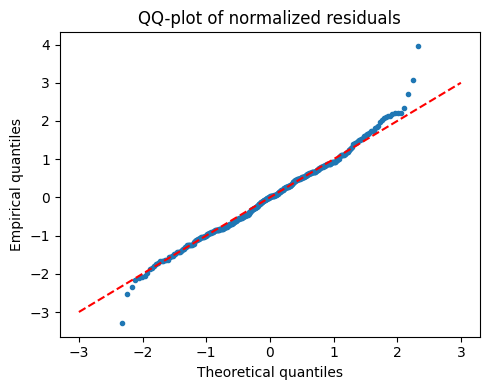

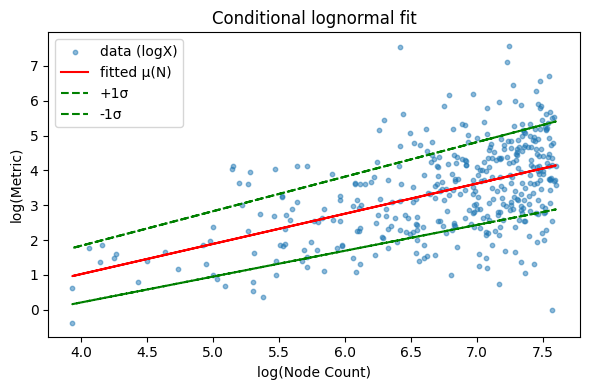

In [3]:
# -----------------------------
# 4. Diagnostics
# -----------------------------
mu_hat = a0 + a1 * df["logN"]
sigma_hat = np.clip(b0 + b1 * df["logN"], 1e-6, None)
resid = (df["logX"] - mu_hat) / sigma_hat

# QQ plot
plt.figure(figsize=(5,4))
norm_prob = np.sort(norm.ppf(np.linspace(0.01,0.99,len(resid))))
plt.plot(norm_prob, np.sort(resid), '.')
plt.plot([-3,3], [-3,3], 'r--')
plt.xlabel("Theoretical quantiles")
plt.ylabel("Empirical quantiles")
plt.title("QQ-plot of normalized residuals")
plt.tight_layout()
plt.show()

# Conditional mean and variance vs N
df["mu_hat"] = mu_hat
df["sigma_hat"] = sigma_hat

plt.figure(figsize=(6,4))
plt.scatter(df["logN"], df["logX"], s=10, alpha=0.5, label="data (logX)")
plt.plot(df["logN"], mu_hat, 'r', label="fitted μ(N)")
plt.plot(df["logN"], mu_hat + sigma_hat, 'g--', label="+1σ")
plt.plot(df["logN"], mu_hat - sigma_hat, 'g--', label="-1σ")
plt.xlabel("log(Node Count)")
plt.ylabel("log(Metric)")
plt.legend()
plt.title("Conditional lognormal fit")
plt.tight_layout()
plt.show()

In [13]:
# Read the Excel files and save in one DataFrame
allowed_ext = ".xlsx"
excel_dir_path = "n_200/"
pdf_file = "n_200/scaling_results-gamma.pdf"
plt_figs = []

all_sheets = sgt_excel_to_dataframe(excel_dir_path, allowed_ext)
print(all_sheets.keys())

dict_keys(['Nodes-Edges', 'Nodes-Edges(Fit)', 'Nodes-Degree', 'Nodes-Degree(Fit)', 'Nodes-Diameter', 'Nodes-Diameter(Fit)', 'Nodes-Density', 'Nodes-Density(Fit)', 'Nodes-ASC', 'Nodes-ASC(Fit)', 'Nodes-ACC', 'Nodes-ACC(Fit)', 'Nodes-BC', 'Nodes-BC(Fit)', 'Nodes-EC', 'Nodes-EC(Fit)', 'Nodes-CC', 'Nodes-CC(Fit)', 'Nodes-GE', 'Nodes-GE(Fit)'])


In [3]:
# Filter the relevant materials and parameters
materials = ['BSE 017', 'BSE 011', 'BSE 024', 'BSE 025']
material_names = ['PAN/CGO', 'Carb. PAN', 'PAN', 'Carb. PAN/CGO']
parameters = ['Nodes', 'Edges', 'AD', 'Diameter', 'GD', 'BC', 'CC', 'EC']

material_labels = {key: name for (name, key) in zip(material_names, materials)}

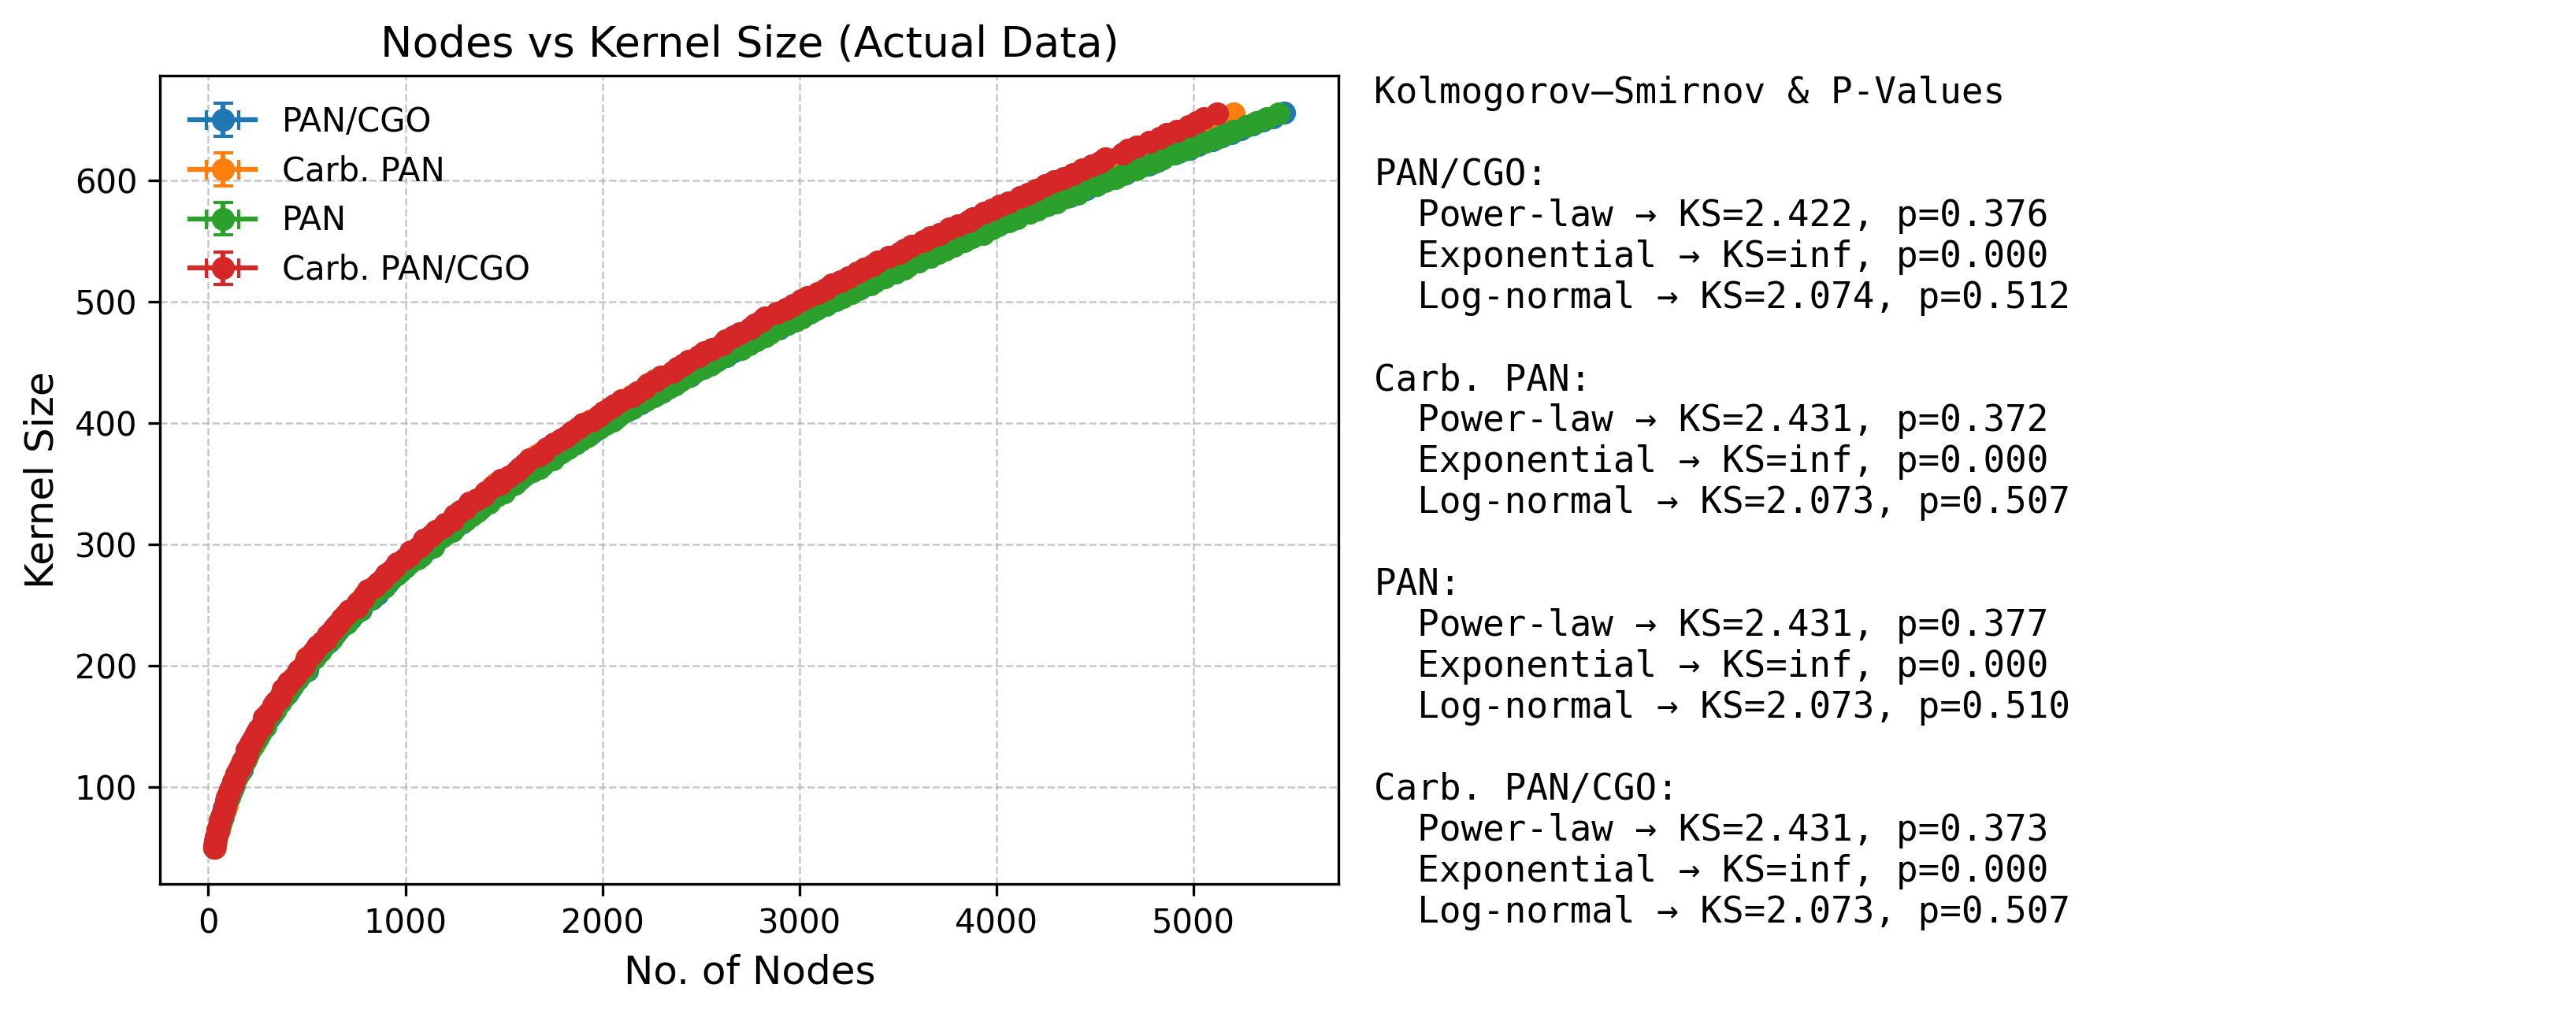

In [4]:
"""
Kernel Size vs Nodes
"""
df_edges = all_sheets['Nodes-Edges']
plt_fig = sgt_scaling_plot("Kernel Size", df_edges, material_labels)
plt_figs.append(plt_fig)

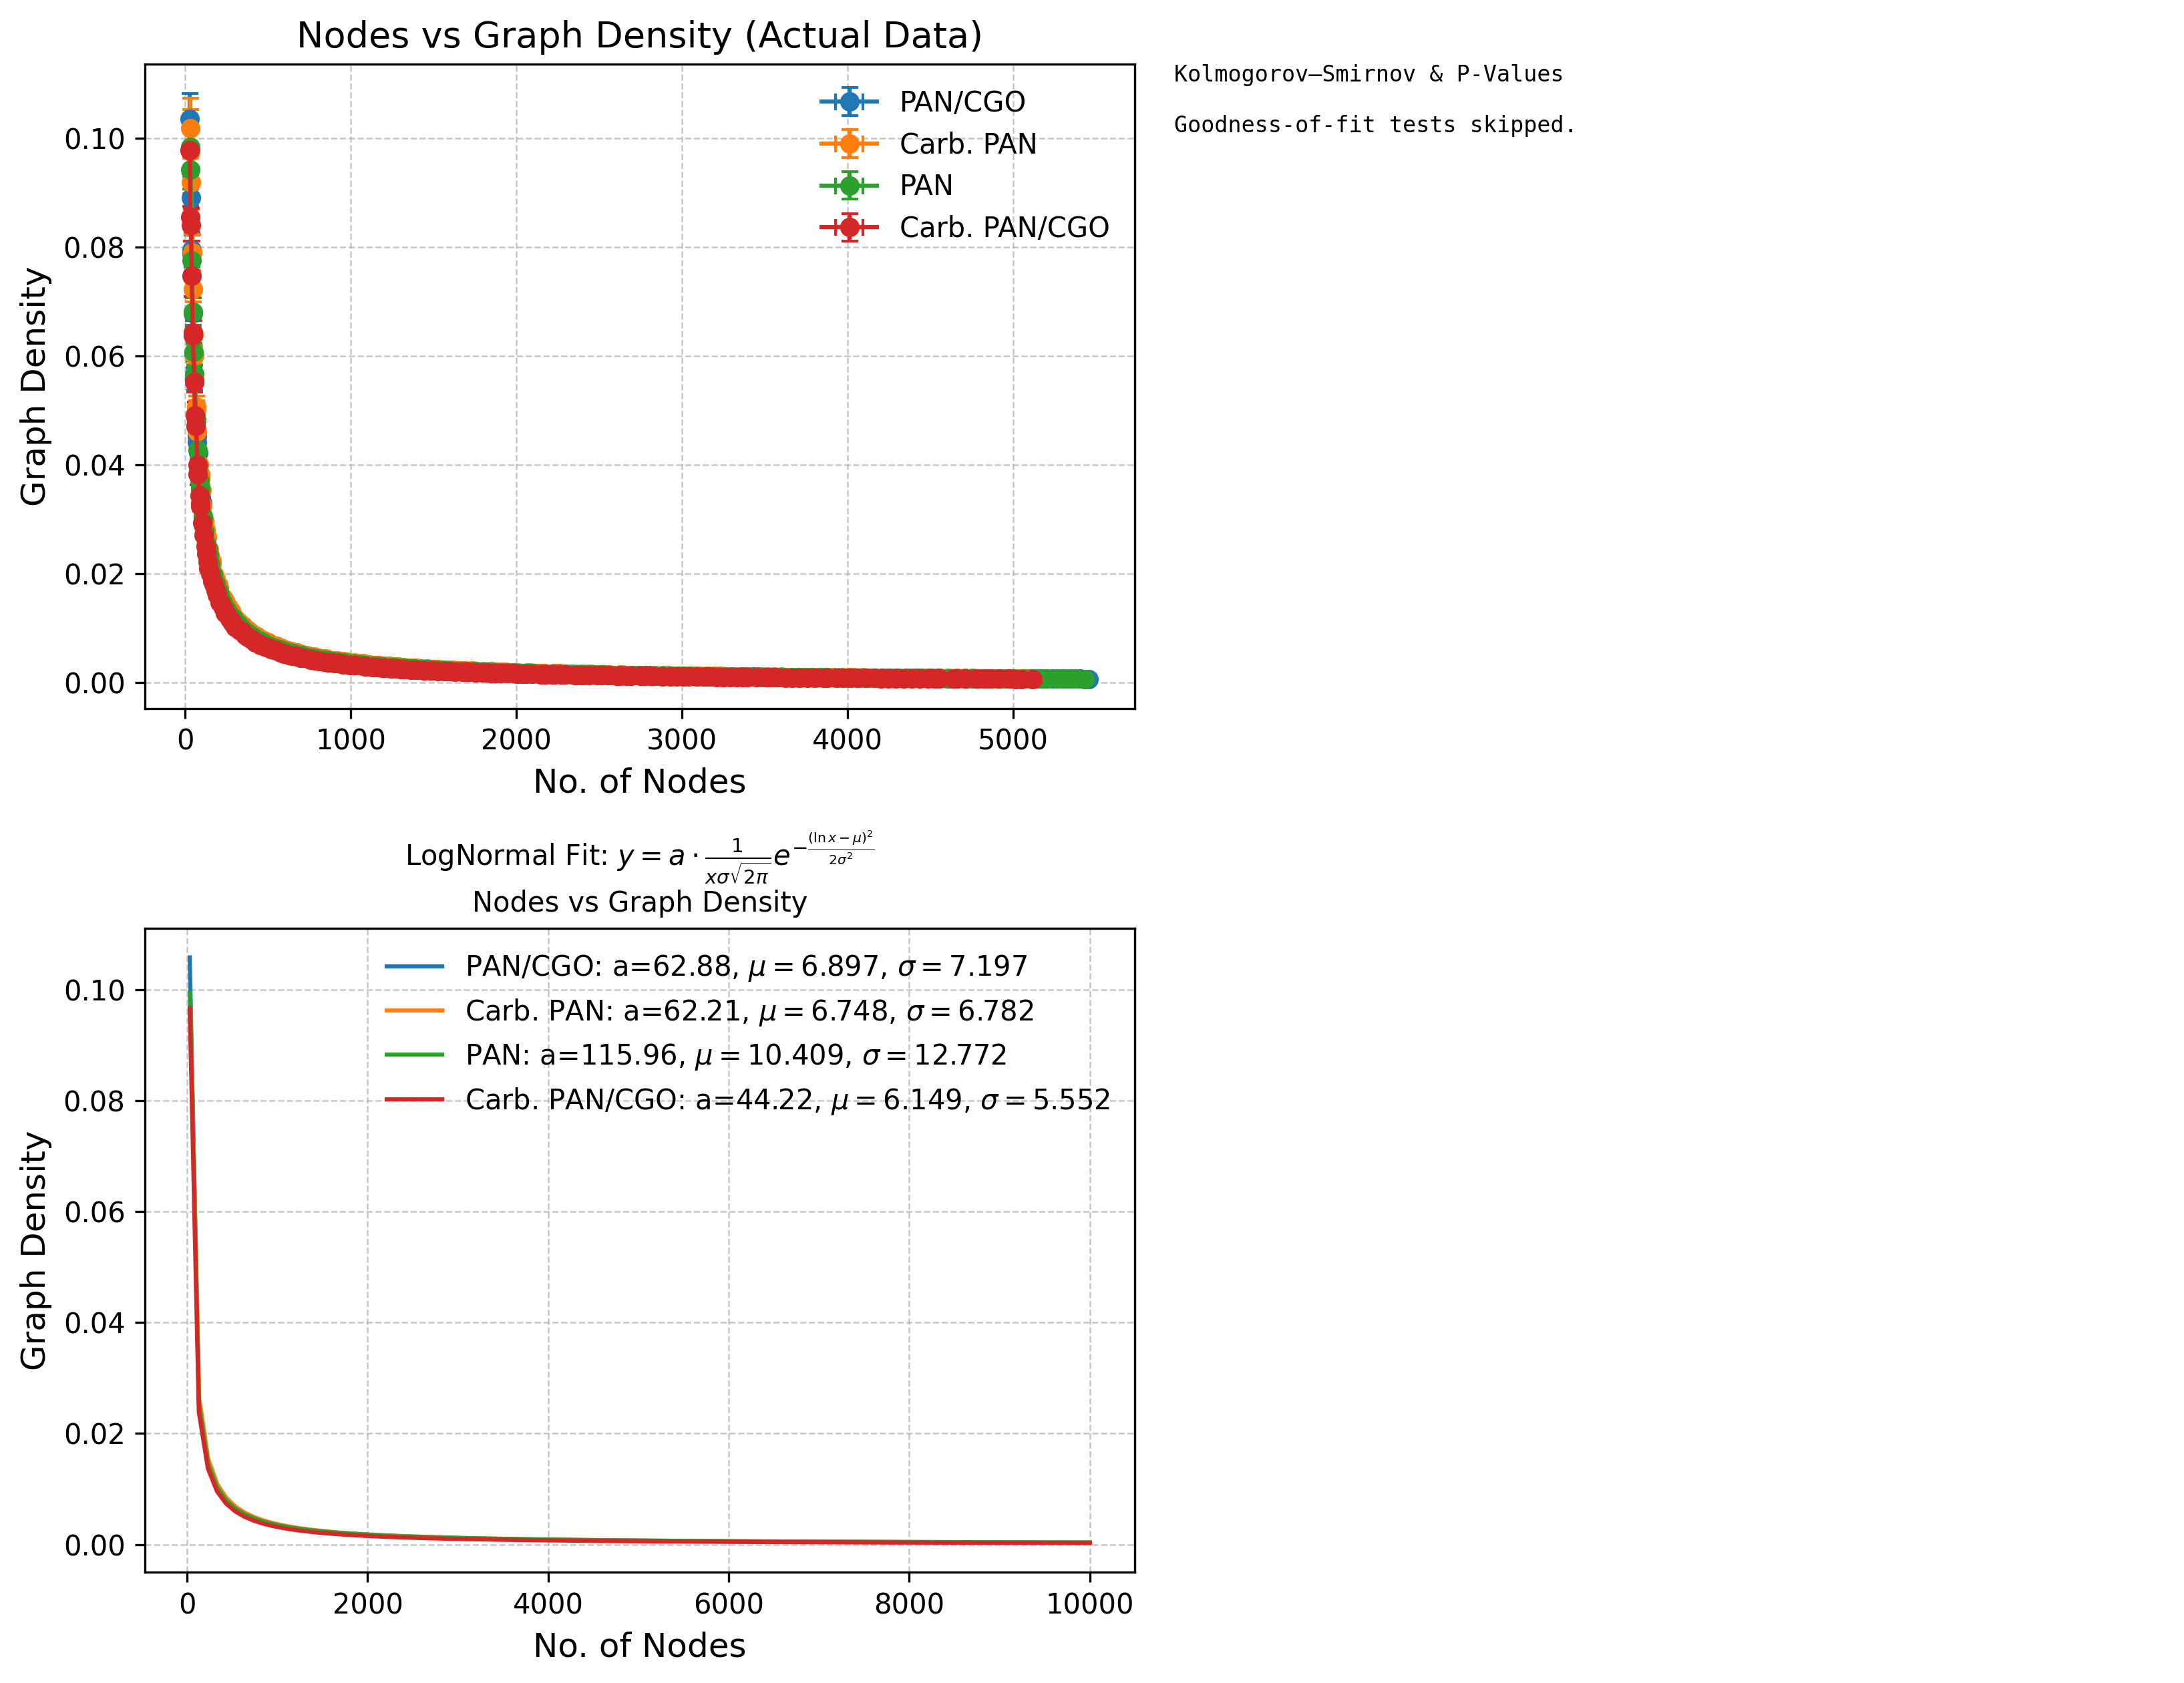

In [14]:
"""
Graph Density
"""
df_dens = all_sheets['Nodes-Density']
plt_fig = sgt_scaling_plot("Graph Density", df_dens, material_labels, skip_test=True, fit_func="lognorm")
plt_figs.append(plt_fig)

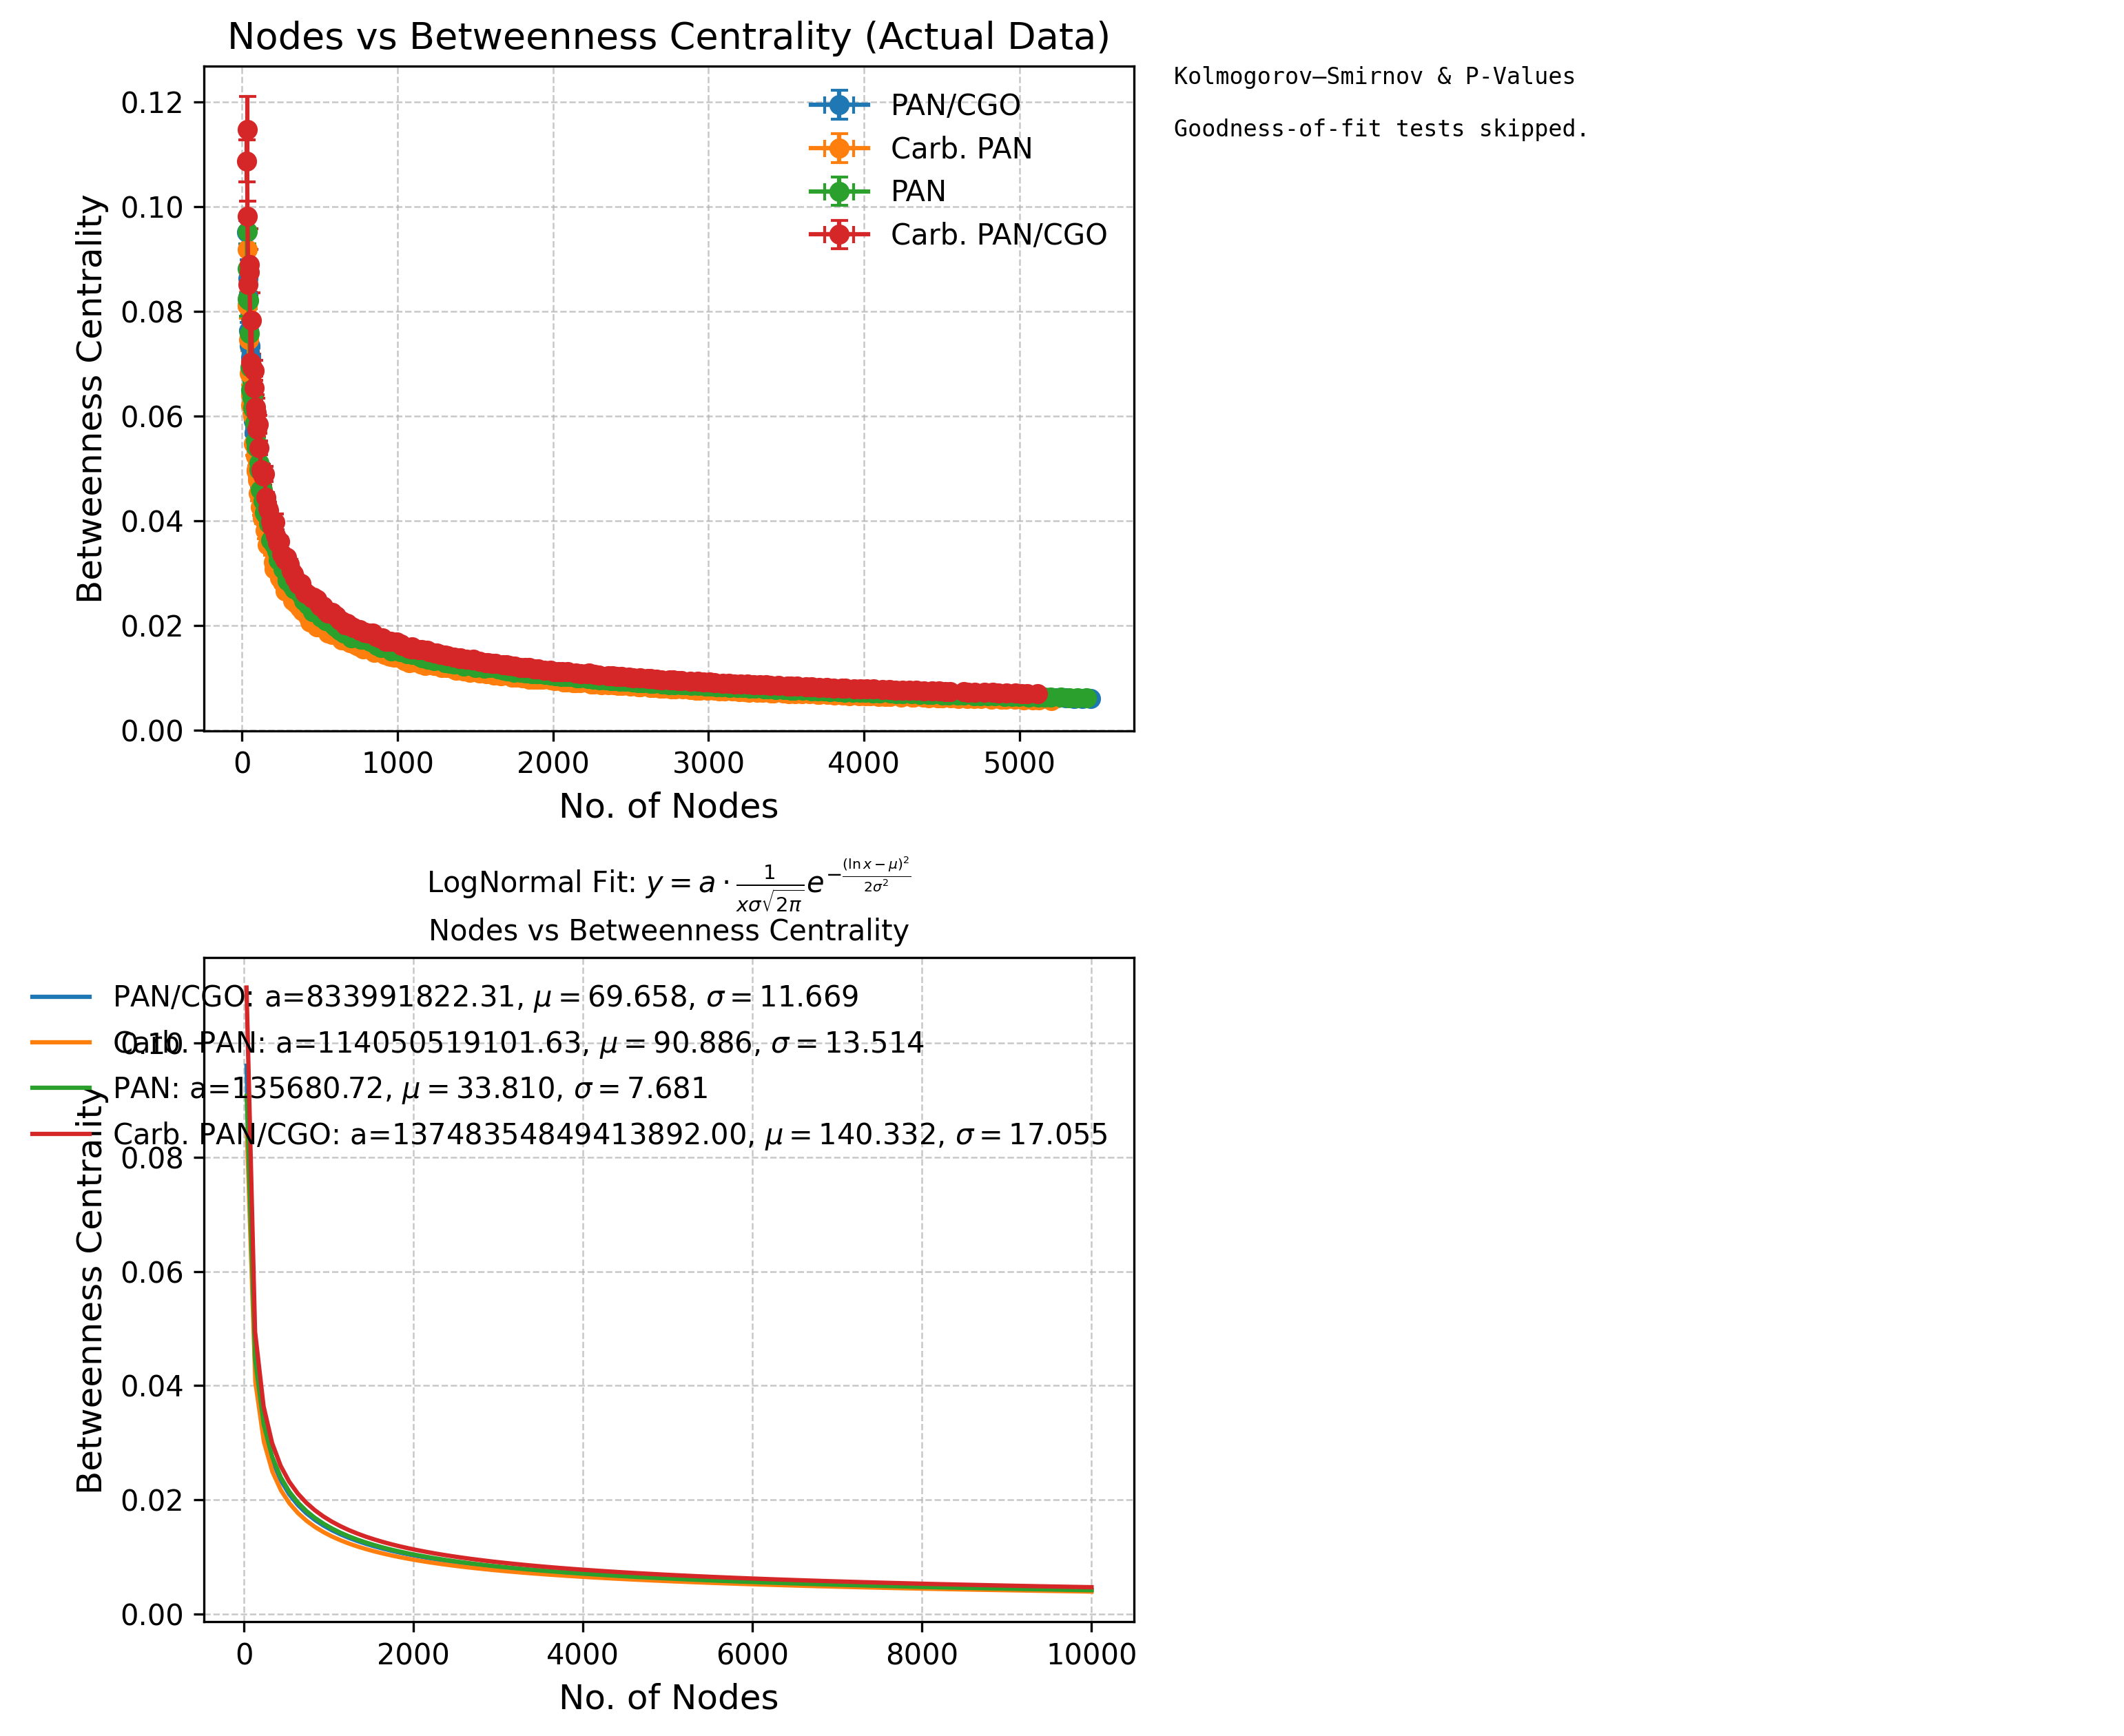

In [15]:
"""
Betweenness
"""
df_bet = all_sheets['Nodes-BC']
plt_fig = sgt_scaling_plot("Betweenness Centrality", df_bet, material_labels, skip_test=True, fit_func="lognorm")
plt_figs.append(plt_fig)

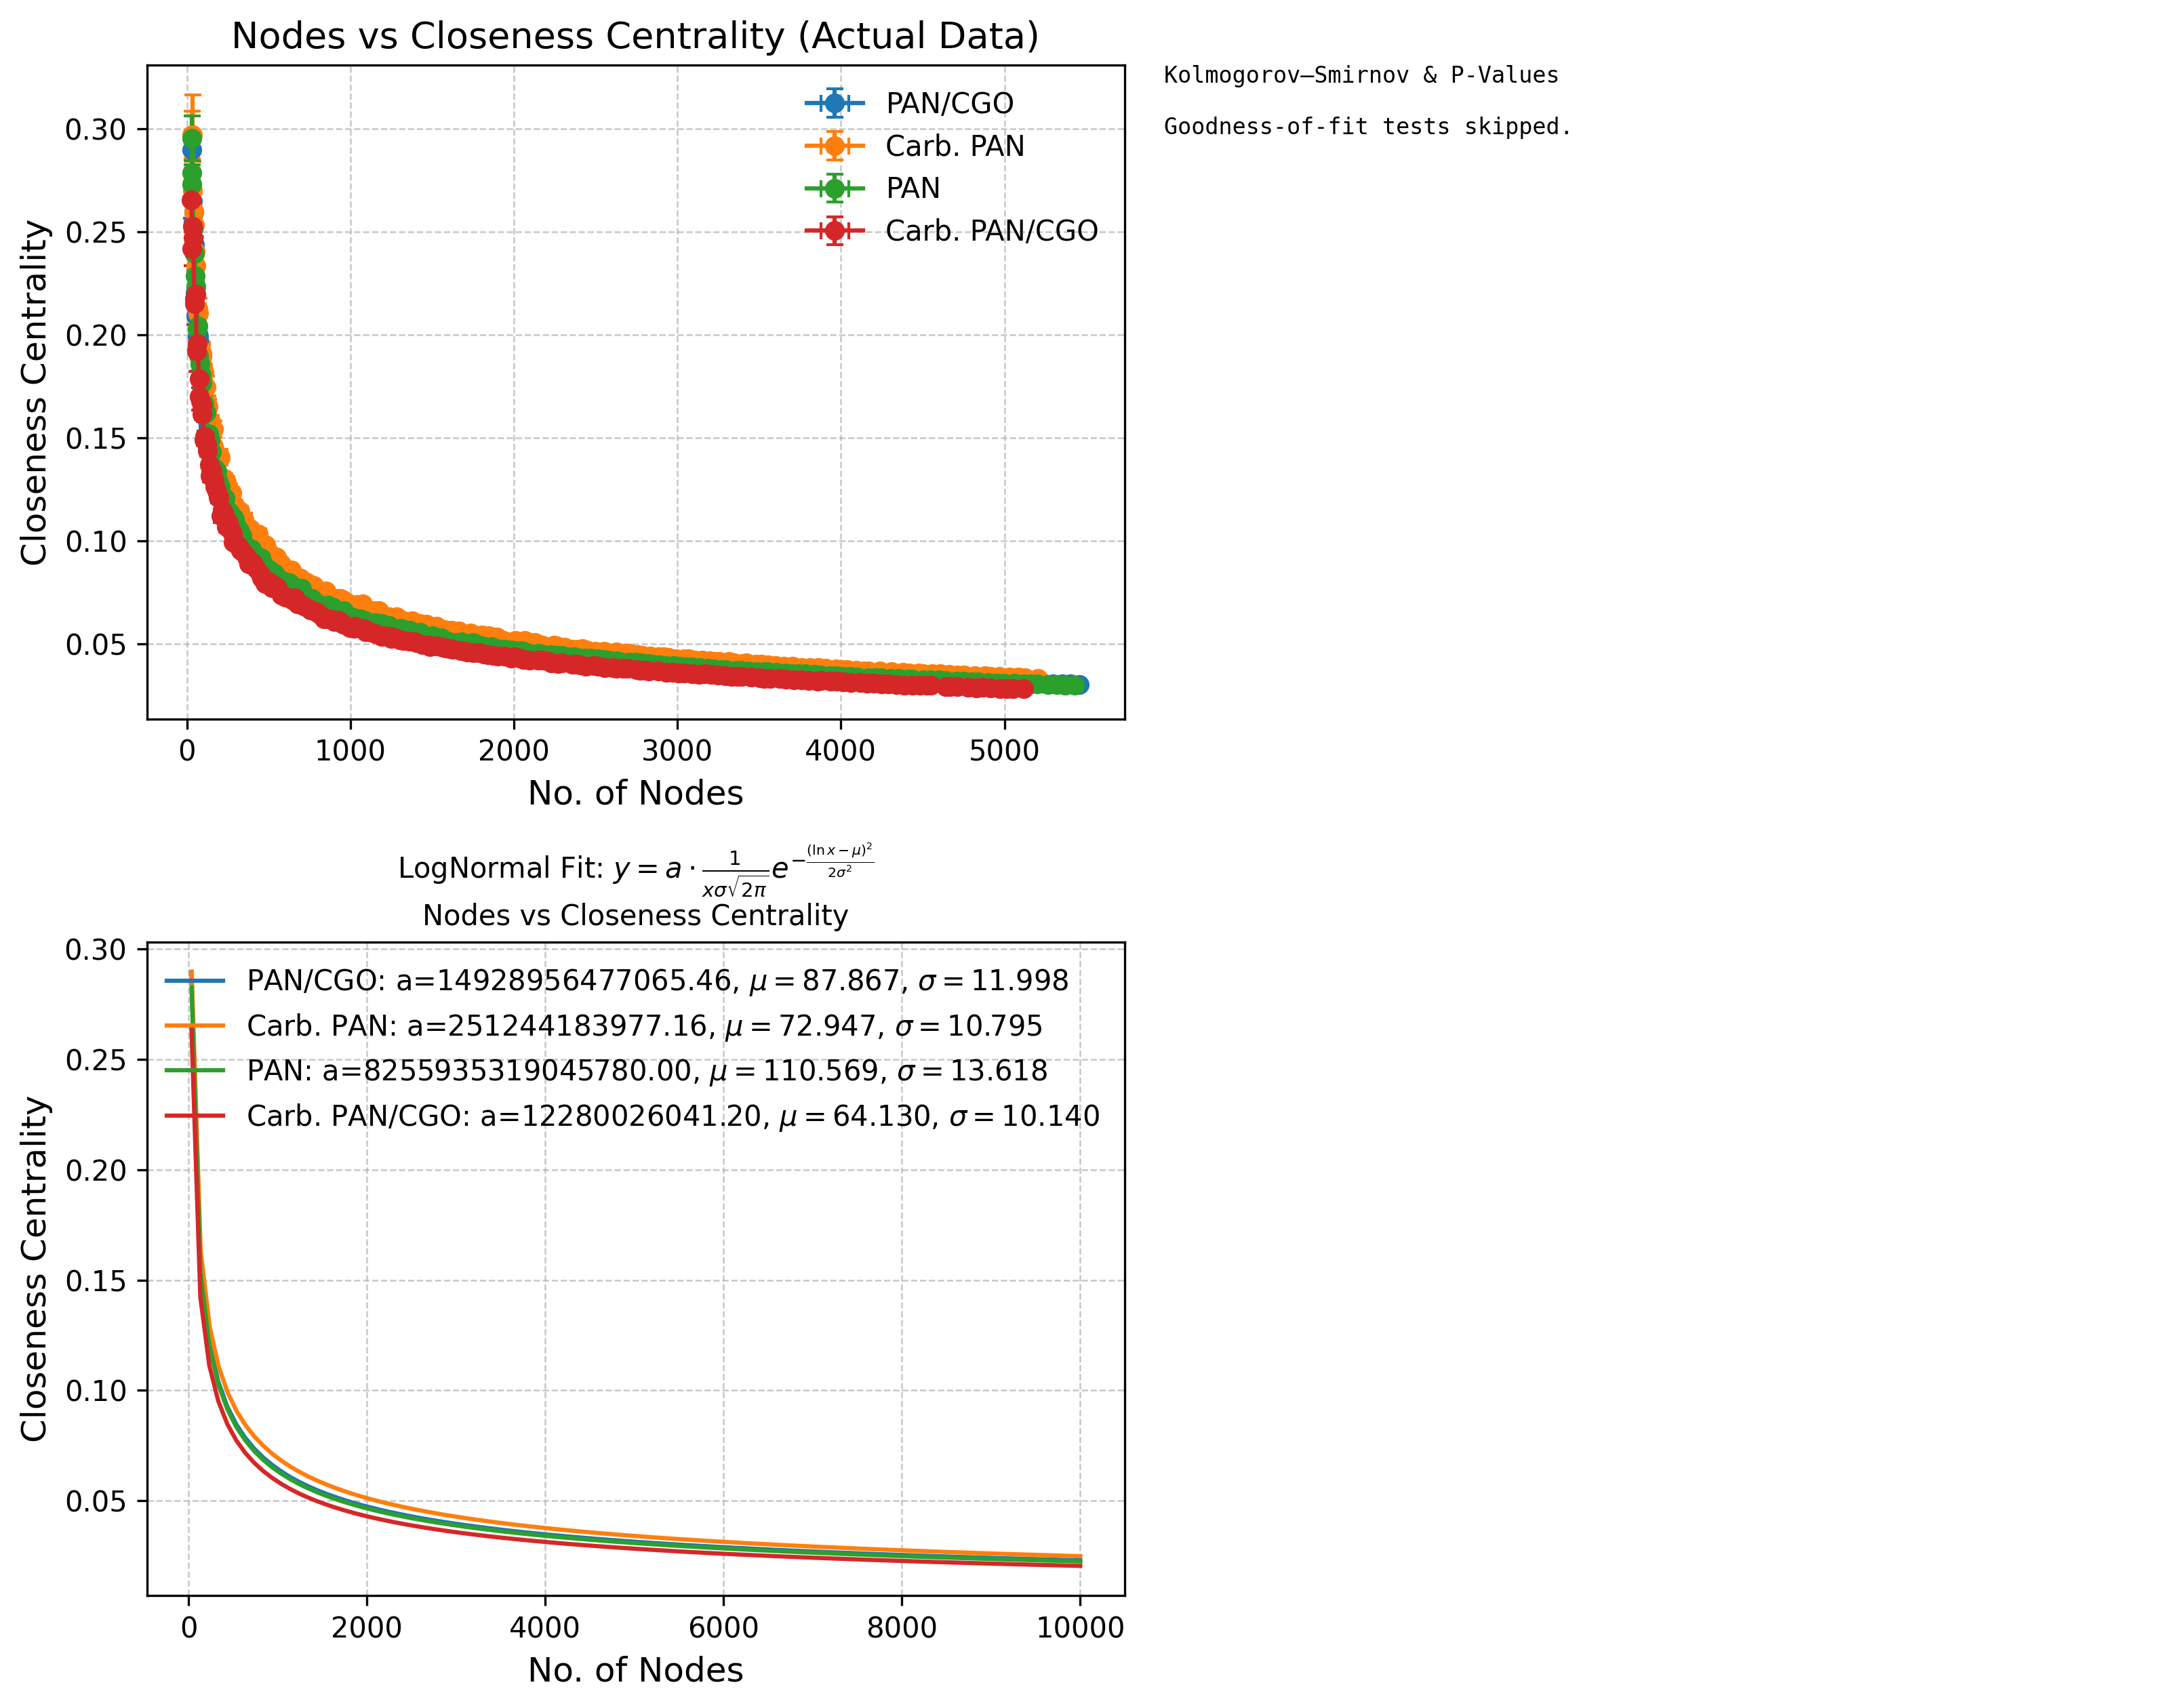

In [16]:
"""
Closeness
"""
df_clo = all_sheets['Nodes-CC']
plt_fig = sgt_scaling_plot("Closeness Centrality", df_clo, material_labels, skip_test=True, fit_func="lognorm")
plt_figs.append(plt_fig)

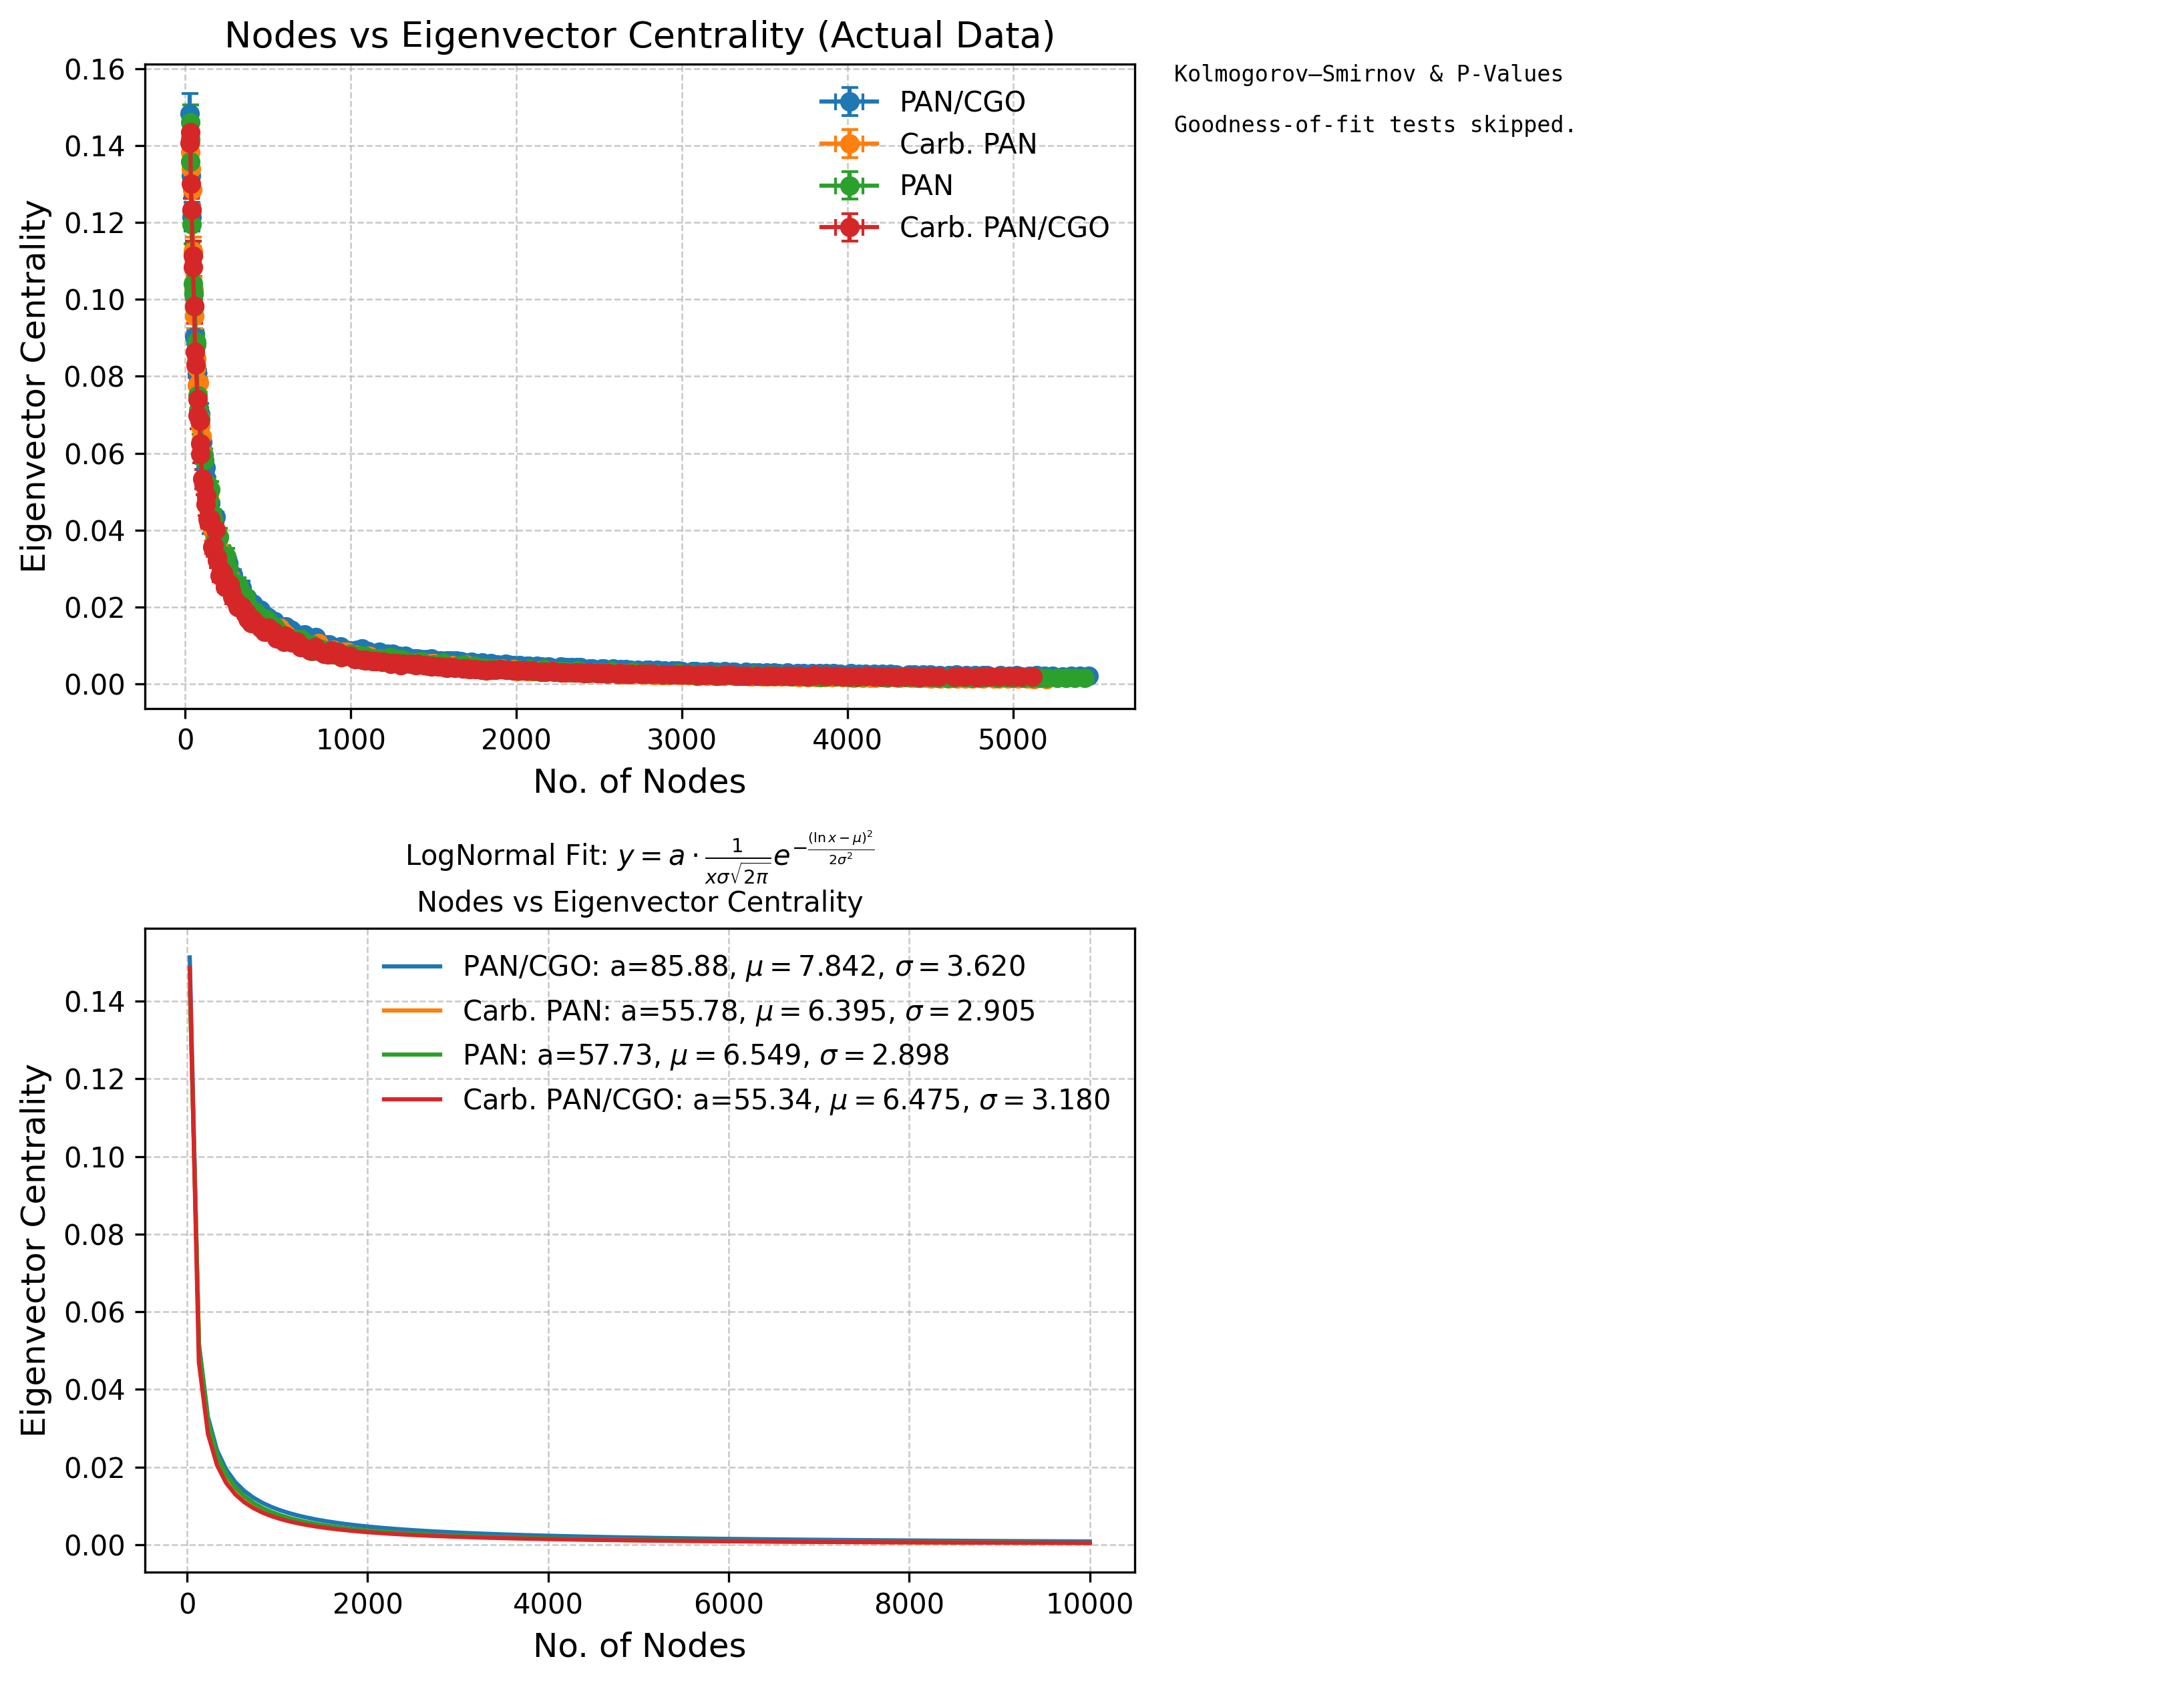

In [17]:
"""
Eigenvector
"""
df_eig = all_sheets['Nodes-EC']
plt_fig = sgt_scaling_plot("Eigenvector Centrality", df_eig, material_labels, skip_test=True, fit_func="lognorm")
plt_figs.append(plt_fig)

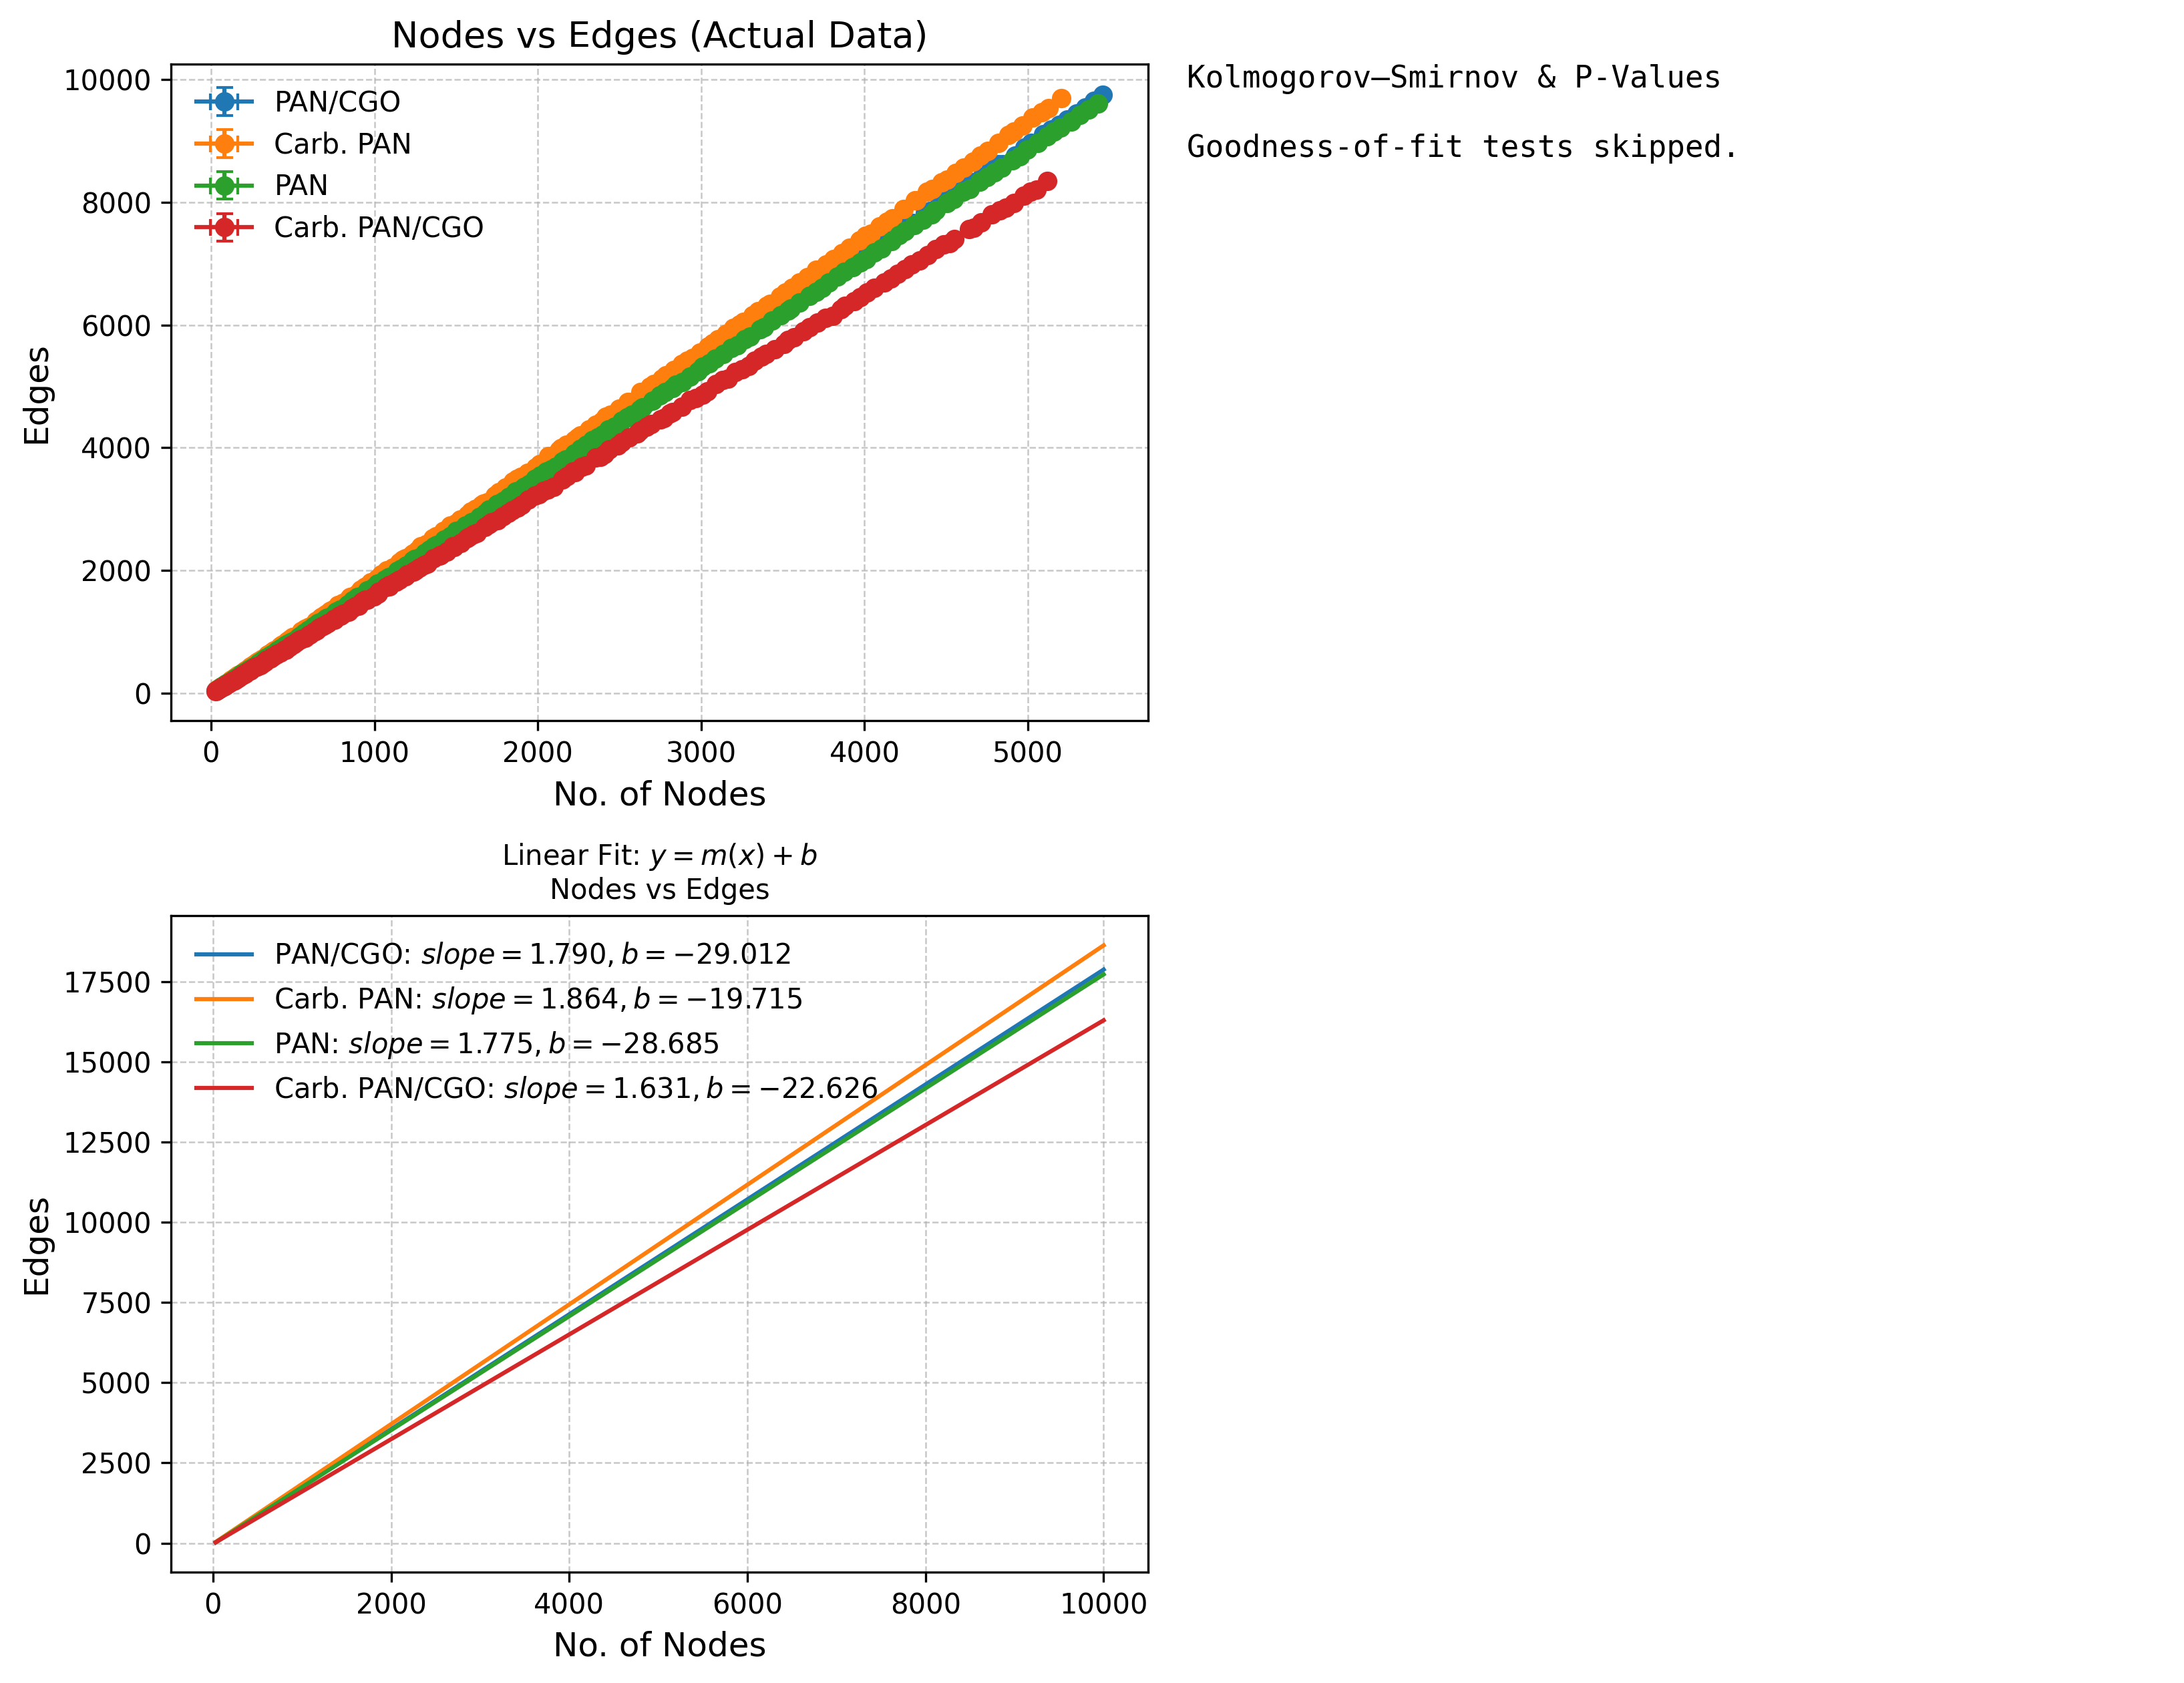

In [4]:
"""
No. Edges
"""
df_edges = all_sheets['Nodes-Edges']
plt_fig = sgt_scaling_plot("Edges", df_edges, material_labels, skip_test=True, fit_func="linear")
plt_figs.append(plt_fig)

Optimal parameters not found: The maximum number of function evaluations is exceeded.
Optimal parameters not found: The maximum number of function evaluations is exceeded.
Optimal parameters not found: The maximum number of function evaluations is exceeded.
Optimal parameters not found: The maximum number of function evaluations is exceeded.


/Users/owuorjnr/owProjects/StructuralGT/src/sgtlib/utils/sgt_utils.py:1279: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax_3.legend(frameon=False)


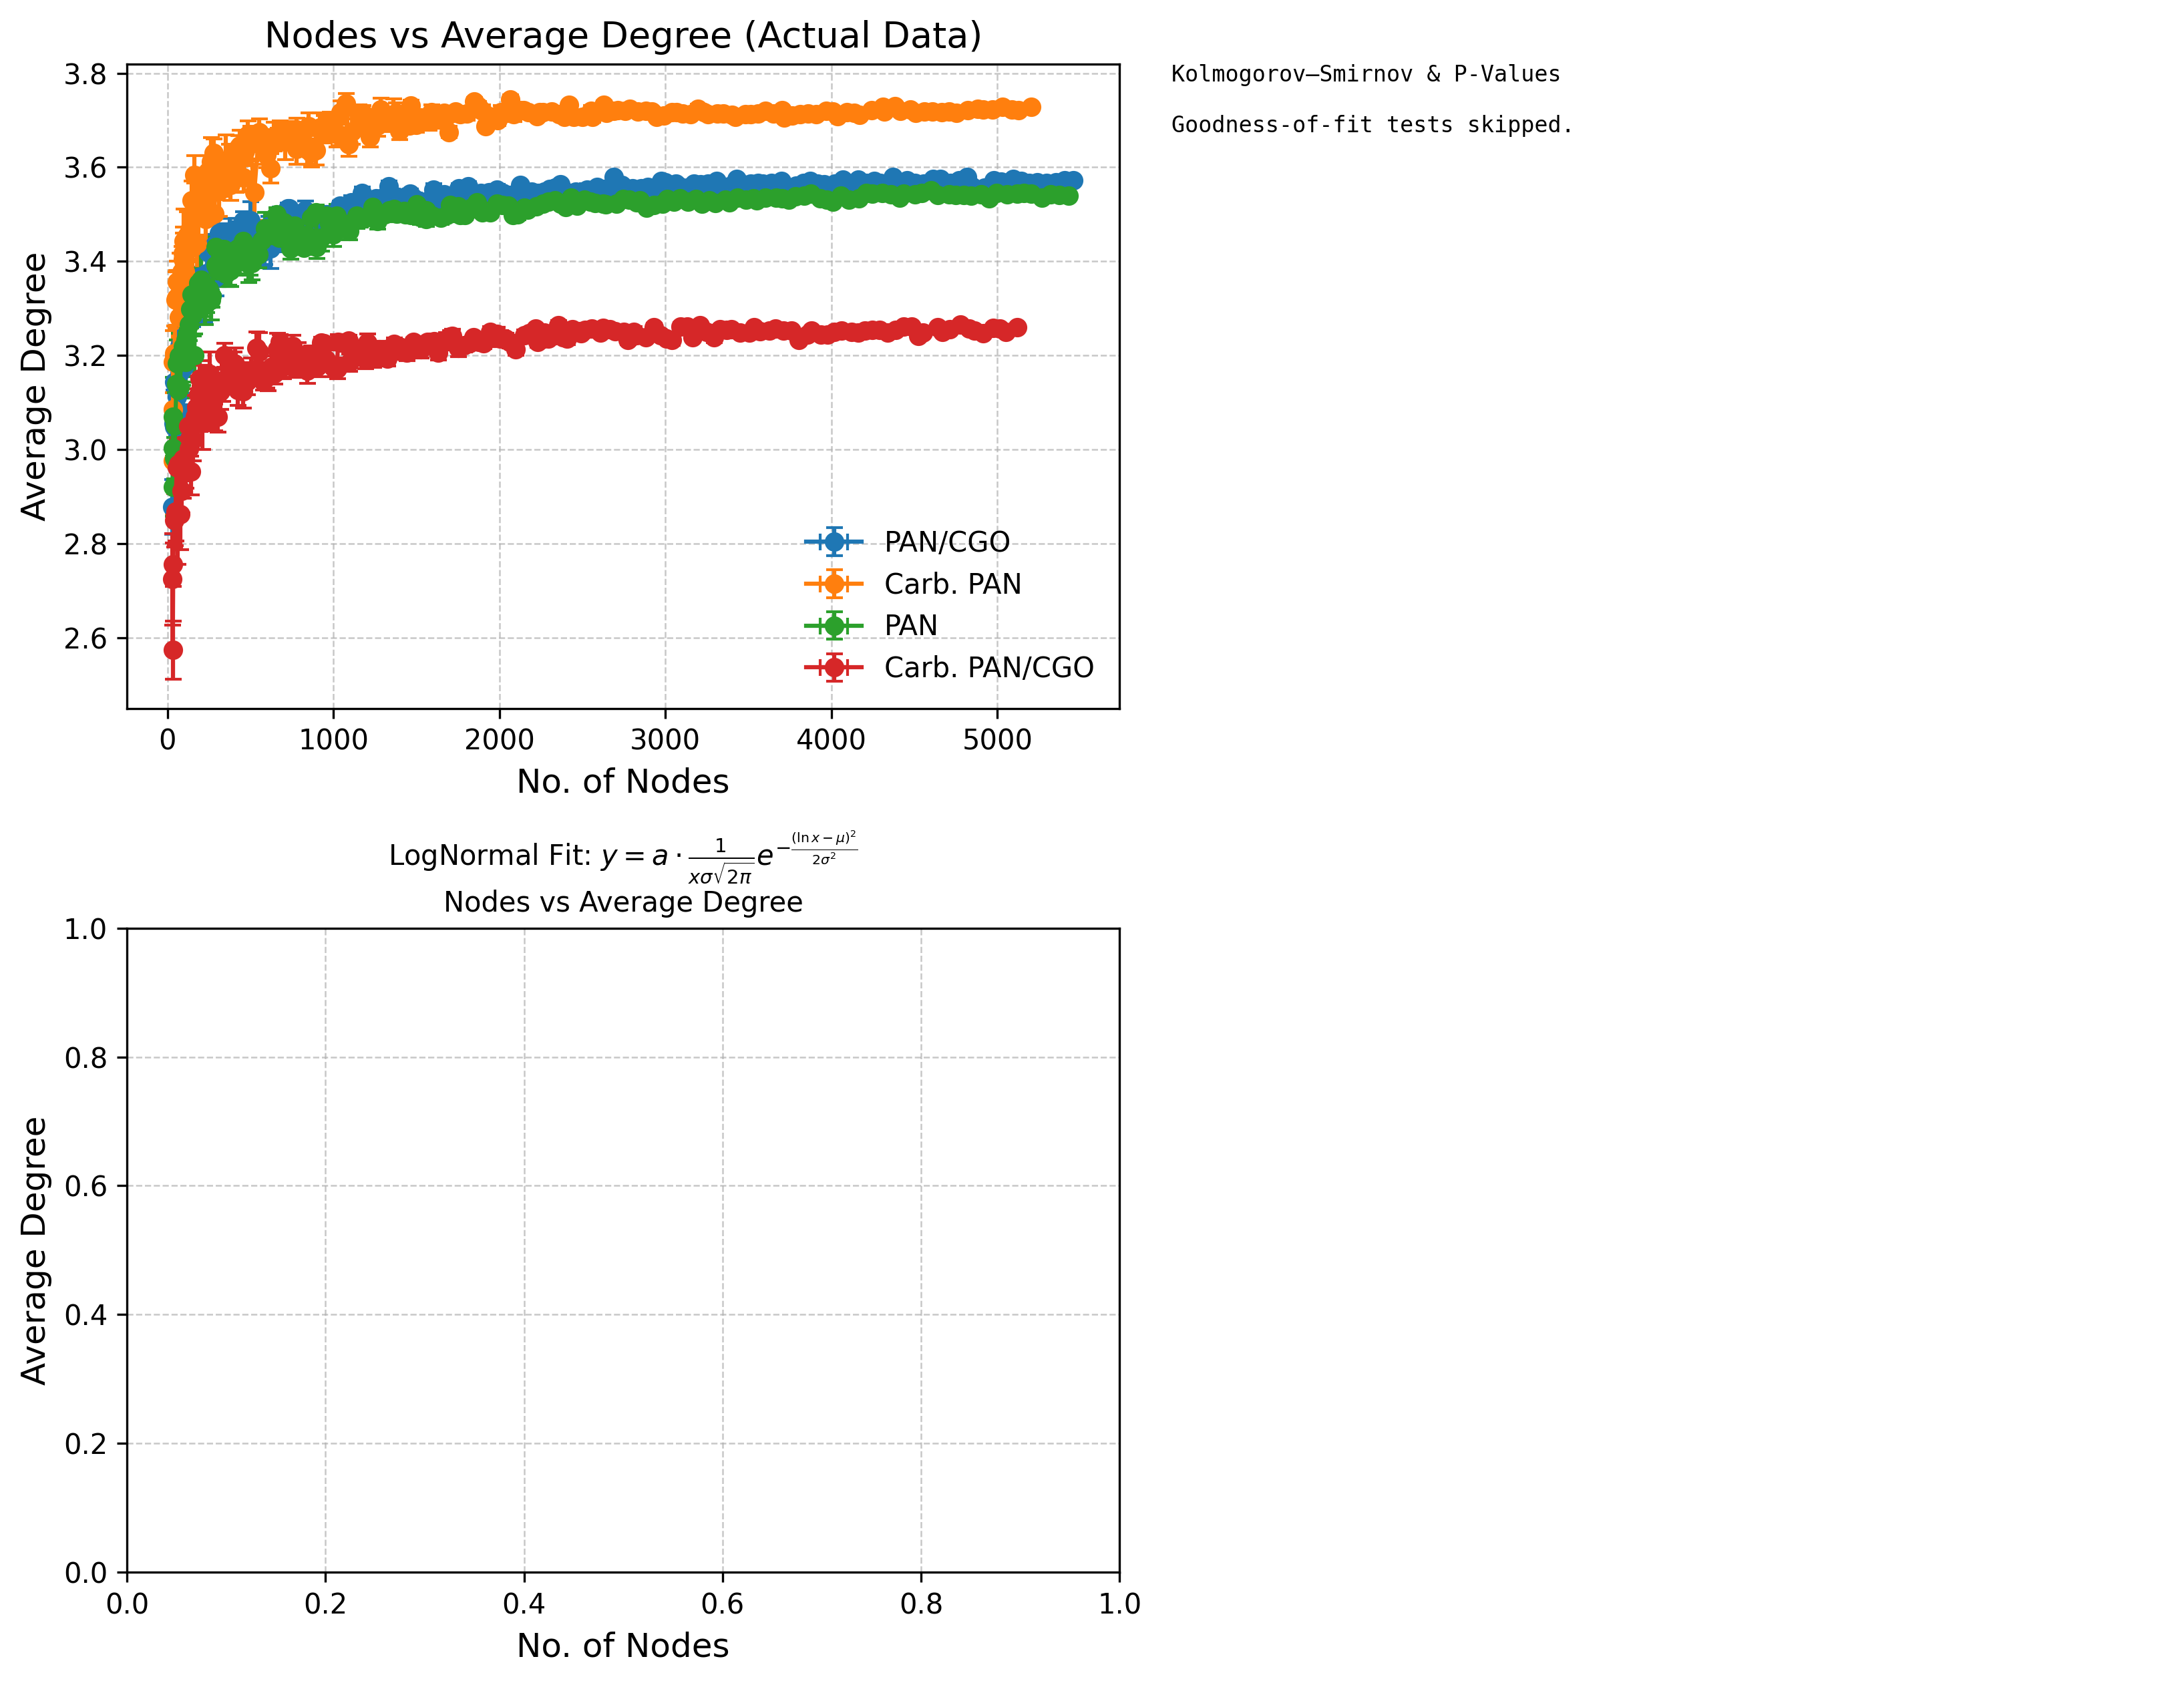

In [18]:
"""
Average Degree
"""
df_deg = all_sheets['Nodes-Degree']
plt_fig = sgt_scaling_plot("Average Degree", df_deg, material_labels, skip_test=True, fit_func="lognorm")
plt_figs.append(plt_fig)

Optimal parameters not found: The maximum number of function evaluations is exceeded.


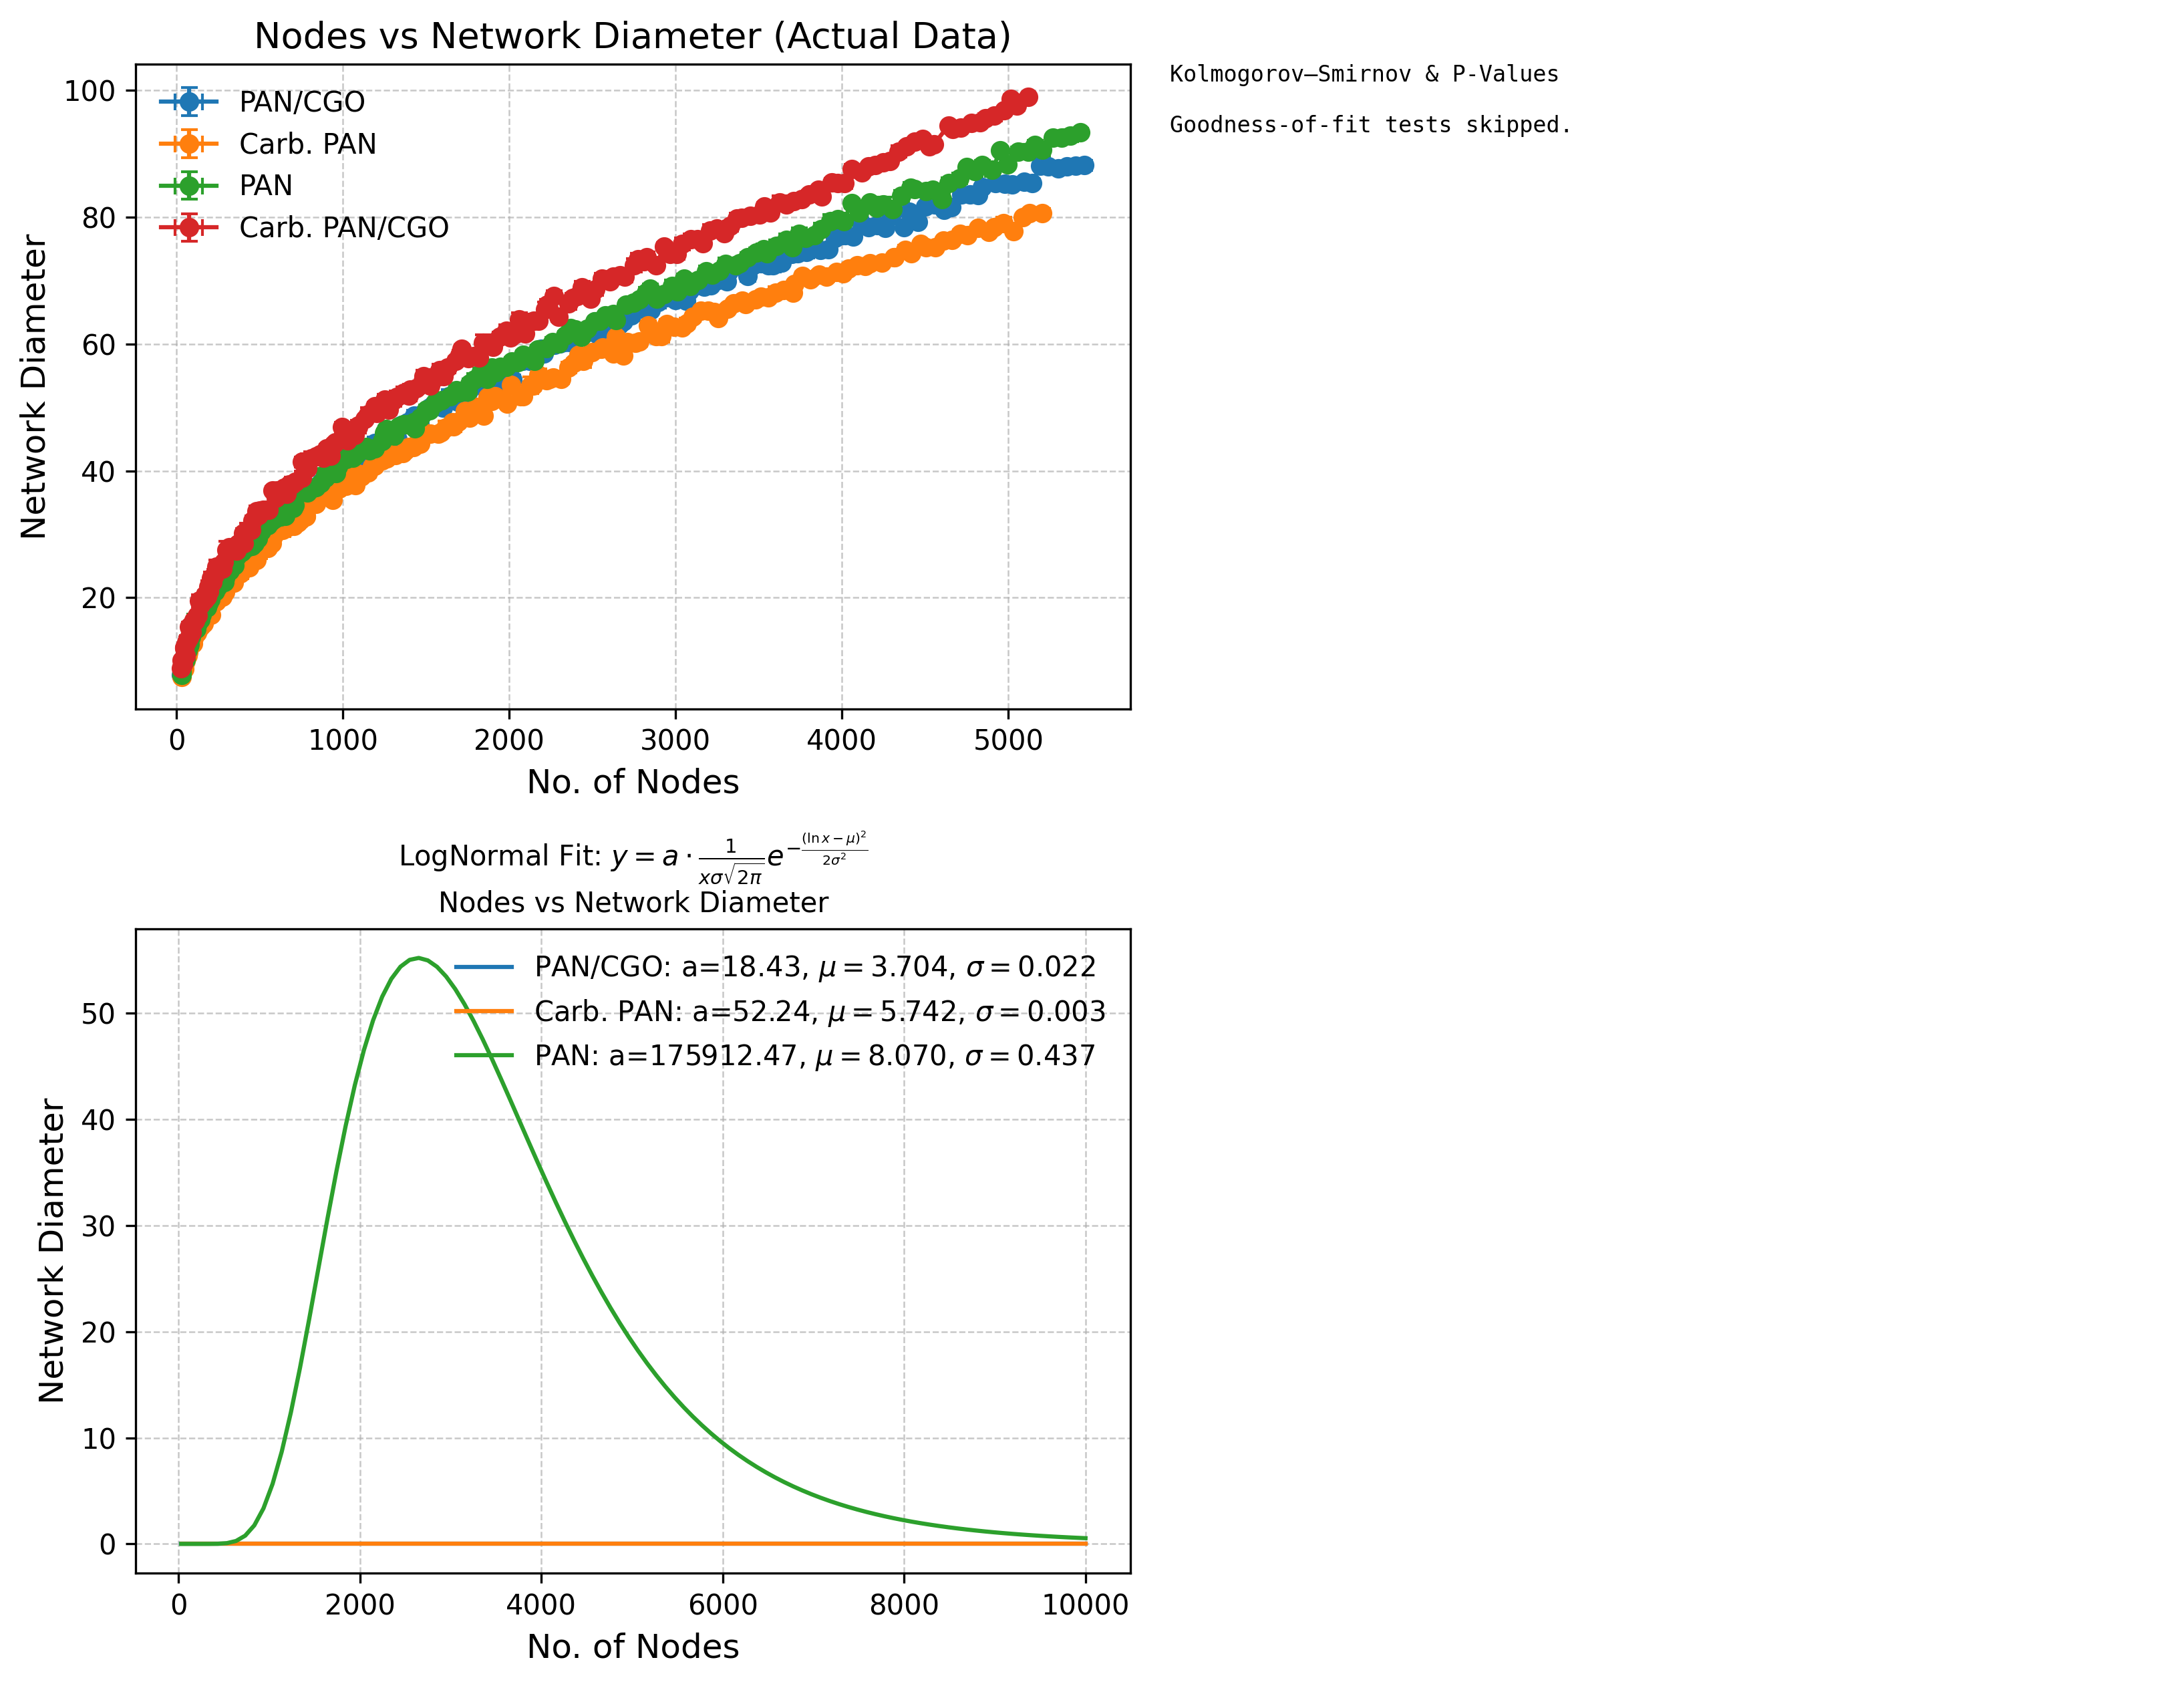

In [20]:
"""
Network Diameter
"""
df_dia = all_sheets['Nodes-Diameter']
plt_fig = sgt_scaling_plot("Network Diameter", df_dia, material_labels, skip_test=True, fit_func="lognorm")
plt_figs.append(plt_fig)

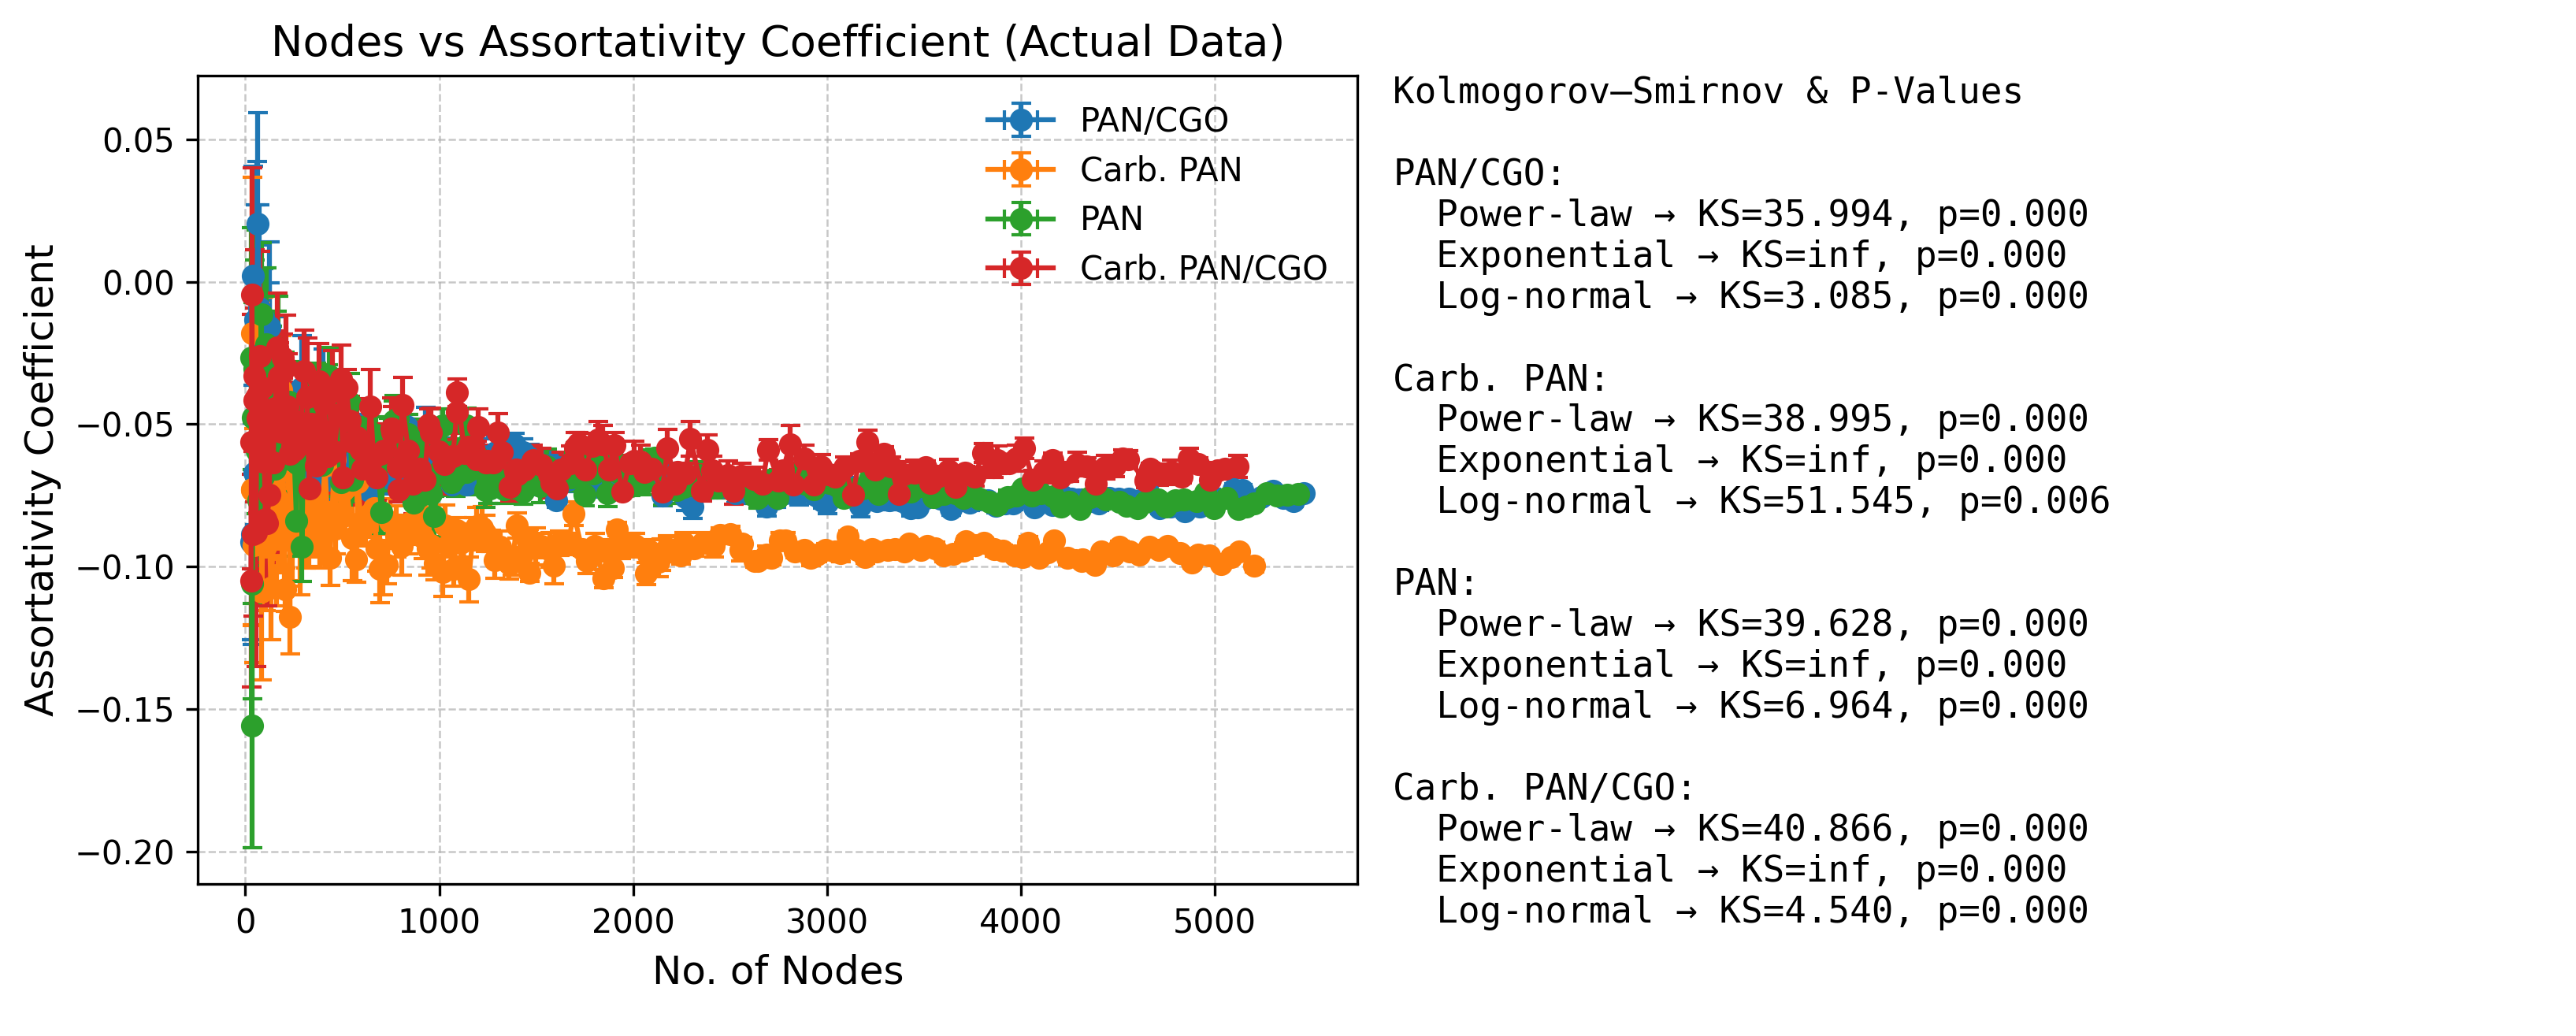

In [12]:
"""
Assortativity Coefficient
"""
df_asc = all_sheets['Nodes-ASC']
plt_fig = sgt_scaling_plot("Assortativity Coefficient", df_asc, material_labels, skip_test=False)
plt_figs.append(plt_fig)

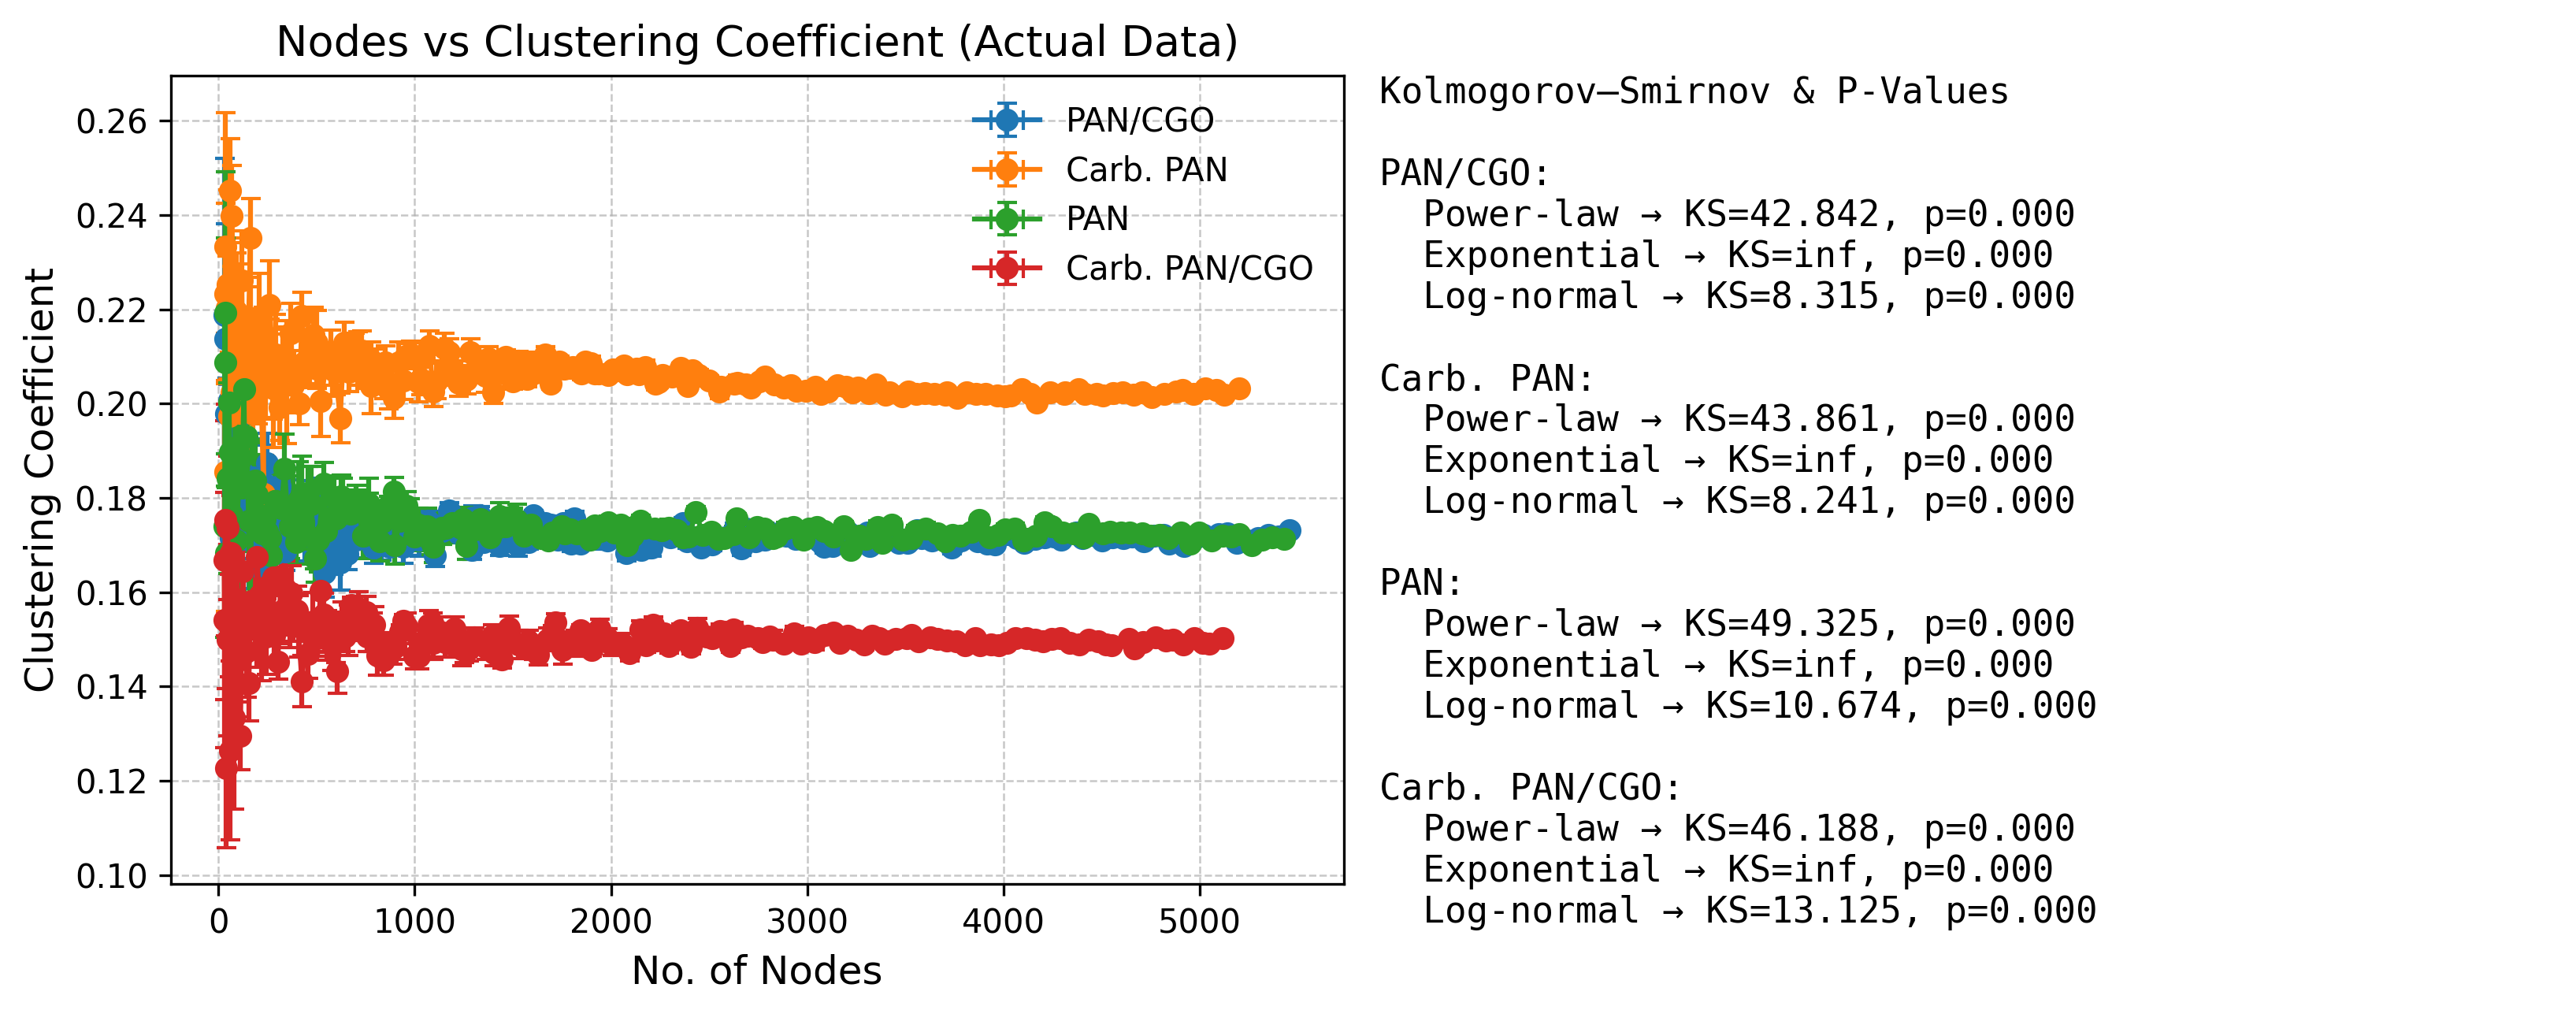

In [13]:
"""
Clustering Coefficient
"""
df_acc = all_sheets['Nodes-ACC']
plt_fig = sgt_scaling_plot("Clustering Coefficient", df_acc, material_labels, skip_test=False)
plt_figs.append(plt_fig)

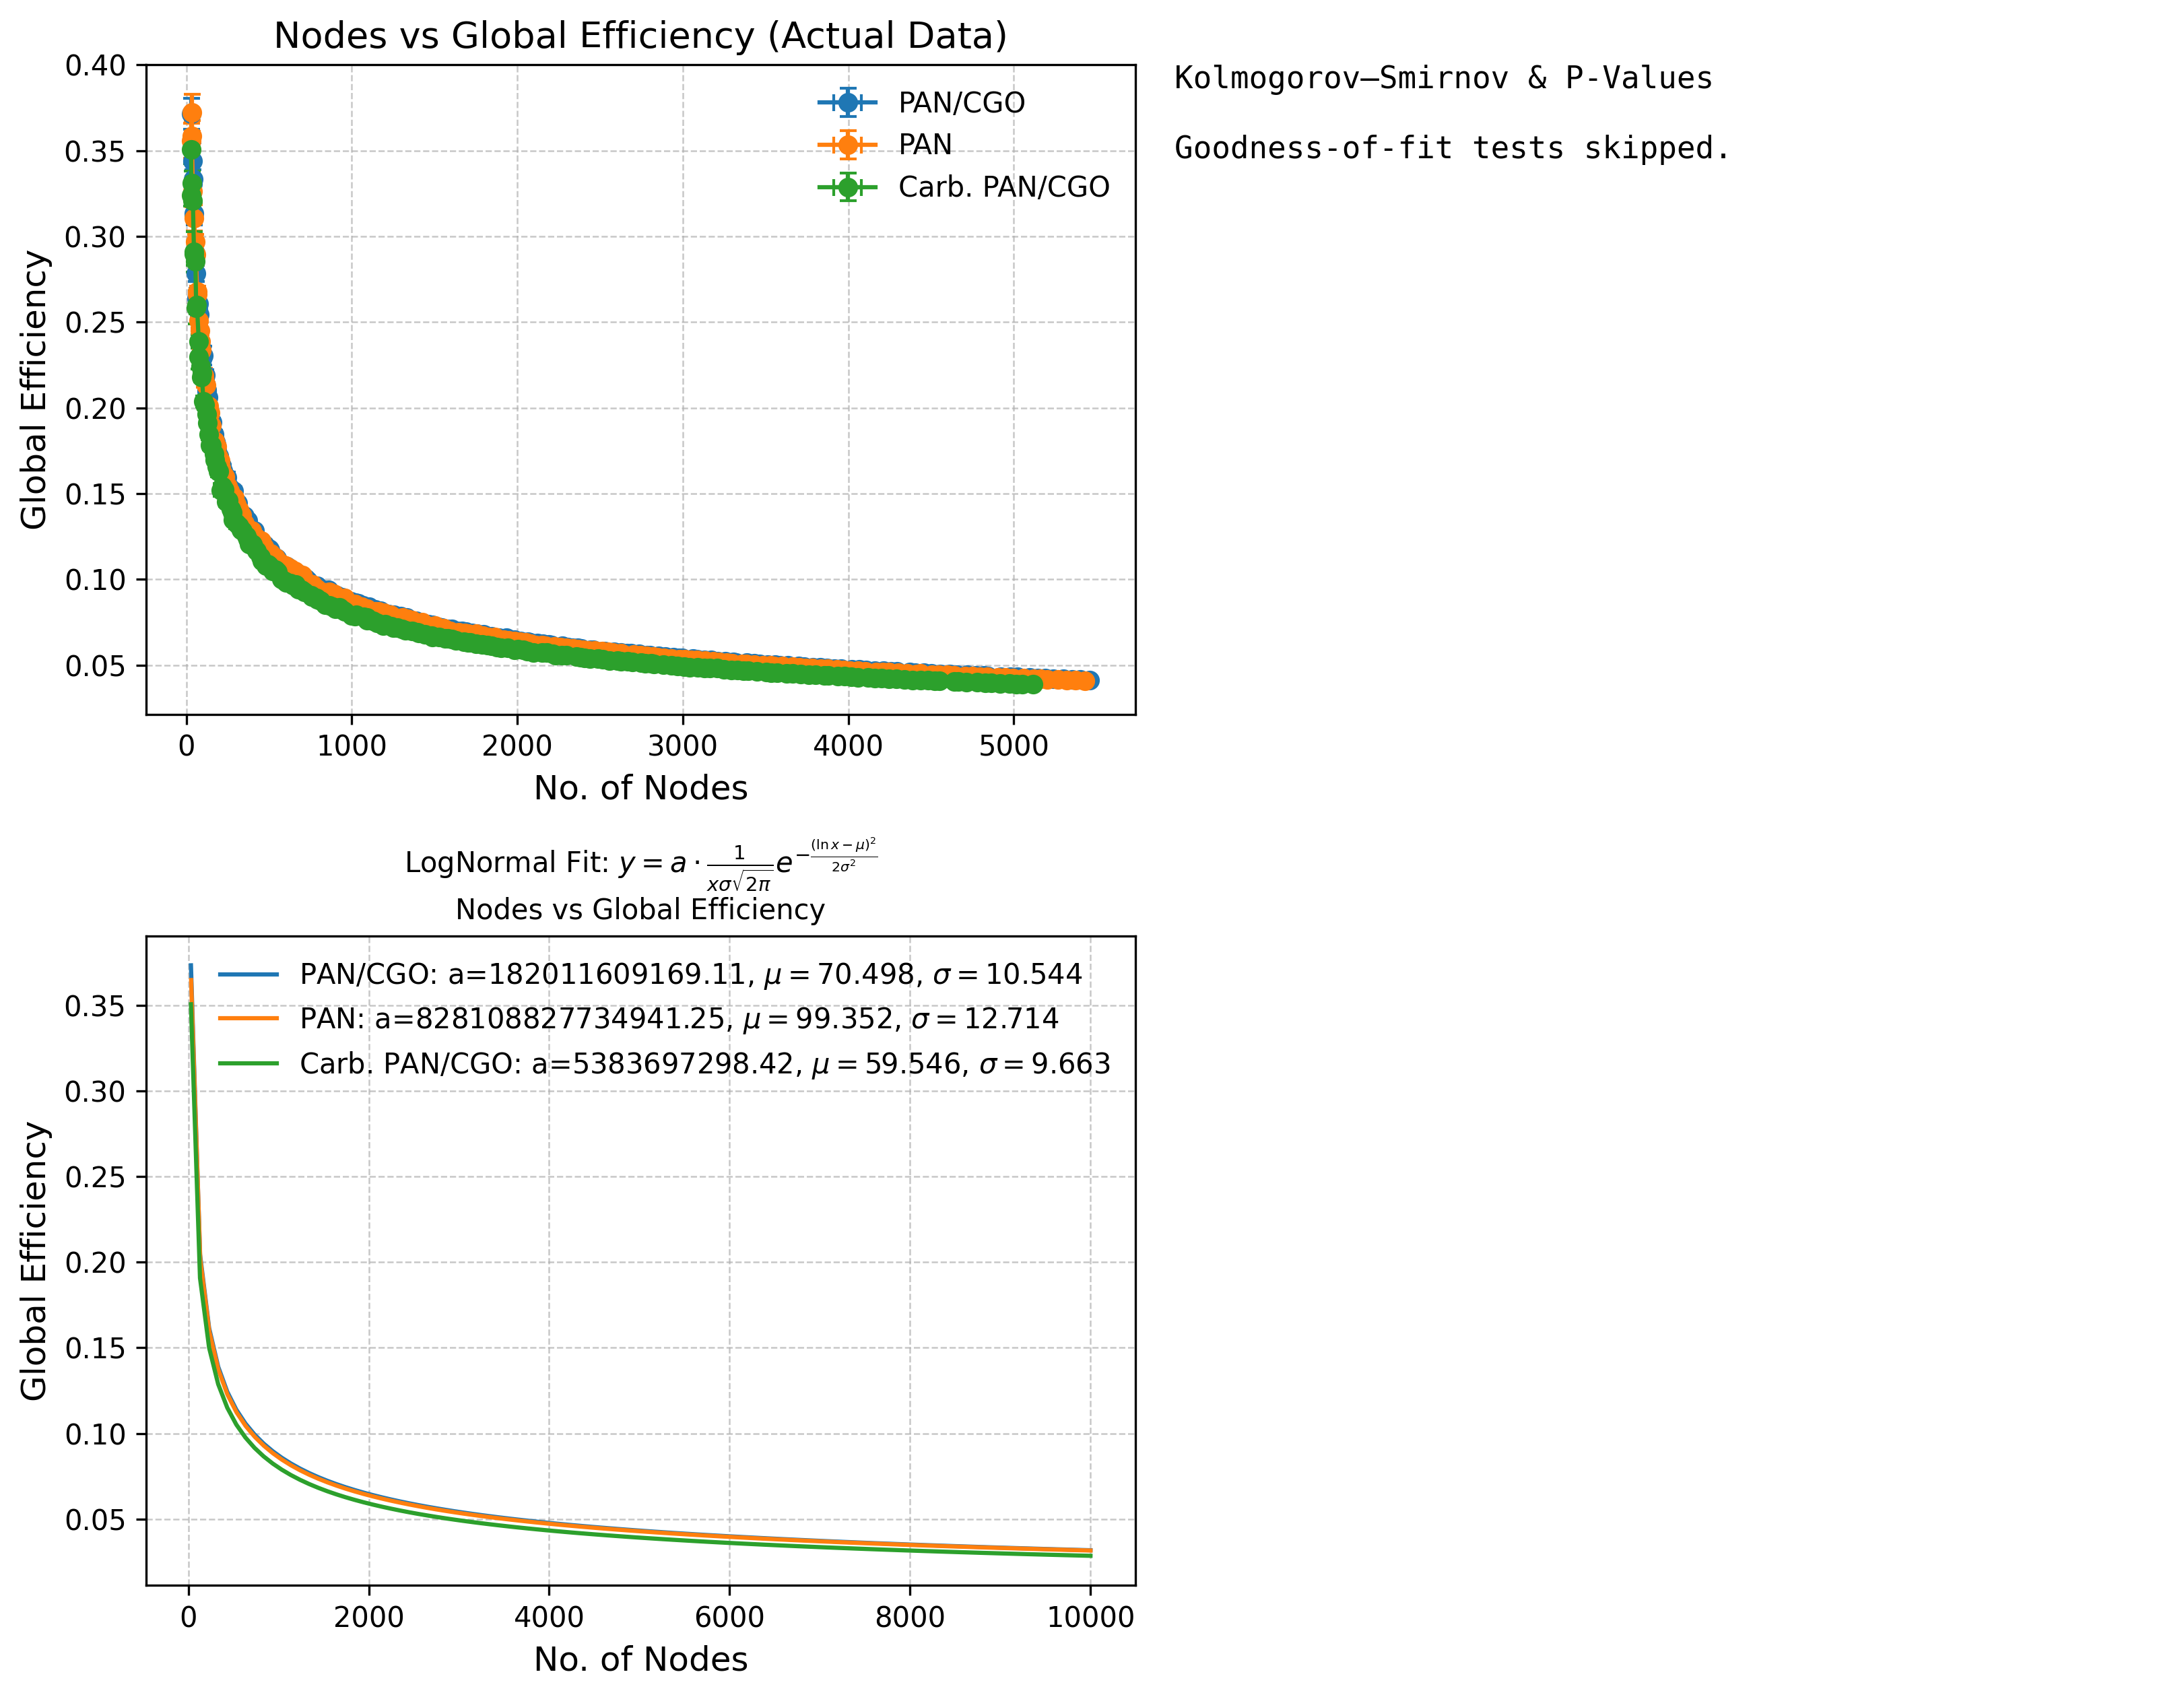

In [5]:
"""
Global Efficiency
"""
df_ge = all_sheets['Nodes-GE']
plt_fig = sgt_scaling_plot("Global Efficiency", df_ge, material_labels, skip_test=True, fit_func="lognorm")
plt_figs.append(plt_fig)

In [21]:
with PdfPages(pdf_file) as pdf:
    for fig in plt_figs:
        pdf.savefig(fig)